
# 4.1. Definirea Problemei: Predicția Intenției de Schimbare a Locului de Muncă (HR Analytics)

### **Context și Relevanță Practică**

&nbsp;&nbsp;&nbsp;&nbsp;Această problemă simulează o provocare reală a departamentelor de Resurse Umane din companiile de tip **Big Data & Data Science**. Compania organizează cursuri de specializare pentru numeroși candidați, însă dorește să optimizeze procesul de recrutare prin identificarea celor care au cu adevărat intenția de a se angaja în cadrul firmei după finalizarea trainingului.

&nbsp;&nbsp;&nbsp;&nbsp;**Impactul soluției de Machine Learning:**
* **Optimizarea Resurselor:** Reducerea costurilor și a timpului investit în candidați care folosesc cursurile doar pentru a-și găsi un alt loc de muncă.
* **Identificarea Riscurilor:** Deoarece aproximativ 24% dintre candidați doresc să plece, modelul trebuie să identifice corect acești subiecți pentru a proteja investiția în training a companiei.
* **Îmbunătățirea Planificării:** Ajustarea calității și tematicii cursurilor în funcție de profilul candidaților reținuți.
* **Înțelegerea Factorilor Decizionali:** Identificarea elementelor care influențează fidelitatea unui specialist (ex. educația, mediul urban, experiența).

---

### **Descrierea Datelor (Dataset Features)**

&nbsp;&nbsp;&nbsp;&nbsp;Pentru a rezolva această sarcină de **clasificare binară**, modelul va analiza următoarele caracteristici (variabile de intrare):

| Categorie | Variabile (Features) |
| :--- | :--- |
| **Identificator** | `enrollee_id` |
| **Demografice & Mediu** | `city`, `city_development_index`, `gender` |
| **Educație** | `relevent_experience`, `enrolled_university`, `education_level`, `major_discipline` |
| **Experiență** | `experience` (ani), `last_new_job` (ani de la ultimul job) |
| **Profil Companie** | `company_size`, `company_type` |
| **Efort Training** | `training_hours` |

---

### **Obiectivul Predicției și Semnificația Claselor**

&nbsp;&nbsp;&nbsp;&nbsp;Scopul modelului este de a prezice variabila țintă `target`, definită astfel:
* **Clasa 0 (Not looking for job change):** Candidatul nu dorește să schimbe locul de muncă (va lucra pentru companie).
* **Clasa 1 (Looking for a job change):** Candidatul caută activ o nouă oportunitate de angajare.

---

### **Motivația alegerii problemei**

&nbsp;&nbsp;&nbsp;&nbsp;**Complexitatea și realismul datelor:** Am ales această problemă deoarece oferă un set de date diversificat, cu variabile categorice și numerice, reflectând fidel dificultățile întâlnite în proiectele autentice de data science din industrie.

&nbsp;&nbsp;&nbsp;&nbsp;**Impactul direct asupra carierei:** Fiind student, o problemă de HR Analytics este extrem de relevantă, oferindu-mi o perspectivă inversă asupra procesului de recrutare și ajutându-mă să înțeleg ce factori sunt cu adevărat valorizați de angajatori.

&nbsp;&nbsp;&nbsp;&nbsp;**Oportunitatea pentru explicabilitate (SHAP):** Natura problemei permite o analiză interesantă a modului în care diferite caracteristici influențează o decizie umană complexă (schimbarea jobului), fiind un context ideal pentru a testa capacitatea modelelor de a "sluji adevărul și discernământul".

> **Observație tehnică:** Setul de date prezintă provocări specifice precum **dezechilibrul claselor** (imbalanced data), prezența multor **variabile categorice** și a **valorilor lipsă**, elemente ce vor fi tratate în etapele de preprocesare.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_full = pd.read_csv('aug_train.csv')

df = df_full.sample(n=2000, random_state=42)
df.shape

(2000, 14)

## 4.2. Analiza Exploratorie a Datelor (EDA) și Pregătirea acestora

&nbsp;&nbsp;&nbsp;&nbsp;Această etapă constituie fundamentul procesului de modelare, având rolul de a transforma „materia primă” a setului de date într-o resursă informațională validă. Obiectivul central al EDA este dublu: înțelegerea mecanismelor interne ale datelor și justificarea riguroasă a fiecărei decizii de curățare sau transformare ce va fi aplicată ulterior.

### Interpretarea Structurii și Calității Datelor**

&nbsp;&nbsp;&nbsp;&nbsp;Analiza dimensiunii și a tipurilor de date:**
* **Structura generală:** Setul de date selectat cuprinde **2000 de observații** și **14 coloane**.
* **Tipuri de date:** Observăm un mix de variabile **numerice** (`float64`, `int64`) și **categoriale** (`object`). Majoritatea caracteristicilor sunt categoriale, fapt ce va necesita tehnici de codificare (encoding) riguroase înainte de antrenarea modelelor.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 16144 to 11009
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             2000 non-null   int64  
 1   city                    2000 non-null   object 
 2   city_development_index  2000 non-null   float64
 3   gender                  1558 non-null   object 
 4   relevent_experience     2000 non-null   object 
 5   enrolled_university     1959 non-null   object 
 6   education_level         1960 non-null   object 
 7   major_discipline        1708 non-null   object 
 8   experience              1995 non-null   object 
 9   company_size            1409 non-null   object 
 10  company_type            1396 non-null   object 
 11  last_new_job            1951 non-null   object 
 12  training_hours          2000 non-null   int64  
 13  target                  2000 non-null   float64
dtypes: float64(2), int64(2), object(10)
memo

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
enrollee_id,2000.0,NaN,NaN,NaN,16875.681,9655.265771,5.0,8437.5,16765.5,25244.75,33368.0
city,2000,104,city_103,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_development_index,2000.0,NaN,NaN,NaN,0.830459,0.122708,0.448,0.743,0.91,0.92,0.949
gender,1558,3,Male,1420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relevent_experience,2000,2,Has relevent experience,1429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enrolled_university,1959,3,no_enrollment,1447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,1960,5,Graduate,1196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major_discipline,1708,6,STEM,1504,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience,1995,22,>20,355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,1409,8,50-99,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN


&nbsp;&nbsp;&nbsp;&nbsp;**2. Integritatea datelor și valori lipsă:**
* **Valori lipsă (Missing Values):** Analiza `df.isna().sum()` evidențiază absențe semnificative în coloanele `company_type` (604), `company_size` (591) și `gender` (442). Acestea vor fi completate cu eticheta "Unknown" pentru a evita pierderea masivă de informație (aproximativ 30% din dataset).

In [5]:
df.isna().sum()

enrollee_id                 0
city                        0
city_development_index      0
gender                    442
relevent_experience         0
enrolled_university        41
education_level            40
major_discipline          292
experience                  5
company_size              591
company_type              604
last_new_job               49
training_hours              0
target                      0
dtype: int64

In [6]:
df.sample(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
7014,19724,city_73,0.754,Male,No relevent experience,no_enrollment,Graduate,STEM,13,NaN,NaN,1,18,1.0
379,4075,city_100,0.887,Male,No relevent experience,Full time course,Graduate,STEM,4,NaN,NaN,1,52,1.0
10614,7389,city_71,0.884,Male,Has relevent experience,no_enrollment,Graduate,STEM,20,10/49,NaN,1,155,1.0
1290,10611,city_71,0.884,Female,No relevent experience,no_enrollment,Phd,STEM,>20,50-99,Public Sector,>4,27,0.0
16315,28987,city_21,0.624,Male,No relevent experience,Full time course,High School,NaN,4,<10,Funded Startup,never,109,0.0
2221,13328,city_21,0.624,Male,Has relevent experience,NaN,Graduate,STEM,14,10000+,Pvt Ltd,1,78,1.0
18778,16433,city_67,0.855,Male,Has relevent experience,no_enrollment,Masters,STEM,8,10000+,Pvt Ltd,>4,3,0.0
14898,6302,city_99,0.915,Male,Has relevent experience,no_enrollment,Graduate,Arts,4,10/49,Pvt Ltd,1,322,0.0
1599,31932,city_83,0.923,Female,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,2,56,1.0
17227,29448,city_158,0.766,Male,No relevent experience,no_enrollment,High School,NaN,1,NaN,NaN,never,83,1.0


**Duplicate:** Am efectuat verificarea duplicatelor excluzând coloana `enrollee_id`, deoarece ID-ul unic ar putea masca existența unor profile identice de candidați. În urma acestei analize, **am identificat și eliminat o înregistrare duplicată la nivel de profil**, asigurând astfel că fiecare observație reprezintă un caz distinct de studiu.


In [7]:
df.duplicated().sum()

np.int64(0)

* **Unicitate:** Coloana `enrollee_id` are 2000 de valori unice, confirmând rolul de identificator administrativ fără valoare predictivă. Aceasta va fi eliminată prin metoda `.drop()`.


&nbsp;&nbsp;&nbsp;&nbsp;** Identificarea potențialelor anomalii:**
* **Cardinalitate ridicată:** Coloana `city` prezintă 104 valori unice, necesitând o atenție sporită la codificare pentru a nu genera un număr excesiv de coloane (curse of dimensionality).

In [8]:
df.nunique()

enrollee_id               2000
city                       104
city_development_index      80
gender                       3
relevent_experience          2
enrolled_university          3
education_level              5
major_discipline             6
experience                  22
company_size                 8
company_type                 6
last_new_job                 6
training_hours             222
target                       2
dtype: int64


&nbsp;&nbsp;&nbsp;&nbsp;**3. Analiza Variabilei Țintă și a Dezechilibrului:**
* **Distribuția Target:** Observăm un **dezechilibru al claselor**:
    * **Clasa 0 (76.3%)**: Candidați care nu doresc schimbarea jobului.
    * **Clasa 1 (23.7%)**: Candidați care caută un nou job.
* **Impact:** Acest dezechilibru indică faptul că **Acuratețea** (Accuracy) nu va fi o metrică relevantă, putând fi înșelătoare. Vom prioritiza **Scorul F1** și **Recall-ul** pentru a identifica corect riscul de plecare al candidaților.


In [9]:
df['target'].value_counts(normalize=True)

target
0.0    0.763
1.0    0.237
Name: proportion, dtype: float64


* **Boltirea și Asimetria:** Indicatorii statistici arată provocări specifice pentru variabilele numerice:

| Variabilă | Skewness | Kurtosis | Interpretare Statistică |
| :--- | :--- | :--- | :--- |
| `city_development_index` | -1.018 | -0.394 | **Asimetrie negativă:** Majoritatea candidaților vin din orașe dezvoltate. |
| `training_hours` | 1.822 | 3.726 | **Leptokurtică (Boltire mare):** Prezență masivă a **outlierilor**. |


In [10]:
df.skew(numeric_only=True)

enrollee_id              -0.007443
city_development_index   -1.018531
training_hours            1.822799
target                    1.237870
dtype: float64

In [11]:
df.kurt(numeric_only=True)

enrollee_id              -1.229195
city_development_index   -0.486740
training_hours            3.749118
target                   -0.468146
dtype: float64

### Identificarea și Eliminarea Duplicatelor

&nbsp;&nbsp;&nbsp;&nbsp;Integritatea setului de date presupune ca fiecare observație să reprezinte un caz unic. Deoarece coloana `enrollee_id` conține identificatori tehnici unici, prezența unor profile identice ar putea fi mascată.

* **Metodologie:** Am efectuat verificarea duplicatelor eliminând temporar coloana de ID, pentru a identifica dacă există candidați cu aceleași caracteristici socio-profesionale.
* **Scop:** Eliminarea înregistrărilor redundante previne denaturarea statisticilor și supra-antrenarea (overfitting) modelelor pe aceleași tipare de date.

In [12]:
duplicate_profiles = df.drop(columns=['enrollee_id']).duplicated().sum()
print(f"Număr profile duplicate (fără ID): {duplicate_profiles}")
df = df.drop_duplicates(subset=df.columns.difference(['enrollee_id']))

print(f"Număr nou de rânduri după eliminare: {df.shape[0]}")

Număr profile duplicate (fără ID): 1
Număr nou de rânduri după eliminare: 1999


### Curățarea și Uniformizarea Datelor

&nbsp;&nbsp;&nbsp;&nbsp;Această etapă asigură integritatea setului de date prin tratarea valorilor lipsă și transformarea variabilelor în format numeric:

* **Imputarea valorilor lipsă:** Pentru coloanele cu volum mare de date absente (`gender`, `company_type`, etc.), am înlocuit valorile nule cu eticheta **'Unknown'** pentru a păstra volumul de date. Pentru restul variabilelor, am eliminat rândurile incomplete (sub 2% din total).
* **Conversia numerică:** Am transformat variabilele categoriale ordinale (`experience`, `last_new_job`) în numere întregi prin maparea intervalelor (ex: ">20" devine 21, "never" devine 0).
* **Validare:** Procesul se încheie cu verificarea eliminării complete a valorilor de tip `NaN`, asigurând un set de date gata pentru antrenare.

In [13]:

cols_to_fix = ['gender', 'company_type', 'company_size', 'major_discipline']
for col in cols_to_fix:
    df[col] = df[col].fillna('Unknown')

df = df.dropna(subset=['enrolled_university', 'education_level', 'experience', 'last_new_job'])

df['experience'] = df['experience'].replace({'>20': '21', '<1': '0'})
df['experience'] = df['experience'].astype(int)

df['last_new_job'] = df['last_new_job'].replace({'never': '0', '>4': '5'})
df['last_new_job'] = df['last_new_job'].astype(int)

print(f"Număr rânduri rămase: {df.shape[0]}")
print(df.isna().sum())

Număr rânduri rămase: 1879
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64


### Analiza Multivariată: Matricea de Corelație

&nbsp;&nbsp;&nbsp;&nbsp;O **matrice de corelație** este un tabel care afișează coeficienții de corelație între variabilele numerice ale setului de date. Fiecare celulă din matrice reprezintă relația dintre două variabile, exprimată printr-o valoare cuprinsă între **-1 și 1**.

* **Scopul Analizei:** Utilizăm această matrice pentru a identifica forța și direcția relațiilor dintre variabile (analiză multivariată). Acest pas este esențial pentru a înțelege cum interacționează caracteristicile între ele și cum influențează variabila țintă (`target`).
* **Interpretarea Valorilor:**
    * **Corelație Pozitivă (apropiată de 1):** Când o variabilă crește, cealaltă tinde să crească și ea (ex: relația dintre experiență și ultimul job schimbat).
    * **Corelație Negativă (apropiată de -1):** Când o variabilă crește, cealaltă scade (ex: relația dintre indexul de dezvoltare al orașului și intenția de plecare).
    * **Valori apropiate de 0:** Indică absența unei relații liniare între variabile.
* **Importanța în Machine Learning:** Vizualizarea sub formă de **Heatmap** ne ajută să detectăm rapid fenomenul de **multicoliniaritate** (variabile prea puternic corelate între ele), care poate distorsiona performanța unor algoritmi precum Regresia Logistică.

### Interpretarea Coeficienților de Corelație

&nbsp;&nbsp;&nbsp;&nbsp;Analizând valorile din matricea de corelație (Heatmap), putem trage concluzii importante despre modul în care trăsăturile angajaților interacționează și cum influențează acestea decizia de părăsire a locului de muncă:

**1. Corelații Semnificative (Relații Directe):**
* **`experience` și `last_new_job` (0.48):** Aceasta este cea mai puternică corelație pozitivă identificată. Aceasta confirmă o relație logică: angajații cu mai mulți ani de experiență acumulată tind să fi trecut prin mai multe schimbări de job de-a lungul carierei.
* **`city_development_index` și `experience` (0.34):** Există o legătură moderată care indică faptul că profesioniștii cu experiență mai mare tind să fie concentrați în orașele cu un indice de dezvoltare ridicat.

**2. Corelații cu Variabila Țintă (`target`):**
* **`city_development_index` și `target` (-0.32):** Aceasta este cea mai importantă corelație pentru modelul nostru. Valoarea negativă indică faptul că, pe măsură ce orașul este mai dezvoltat, probabilitatea ca un angajat să caute un nou job **scade** semnificativ.
* **`experience` și `target` (-0.18):** O corelație negativă care sugerează că persoanele cu senioritate mare sunt, în general, mai stabile la actualul loc de muncă față de candidații aflați la începutul carierei.

**3. Corelații Slabe sau Inexistente:**
* **`training_hours` (aprox. 0.00):** Se observă că numărul de ore de instruire nu are aproape nicio legătură cu celelalte variabile sau cu decizia de a pleca. Acest lucru sugerează că trainingul nu este un factor de predicție decisiv în acest context.
* **`enrollee_id` (0.08):** Valorile foarte mici confirmă că ID-ul este o variabilă pur administrativă, fără relevanță în profilul profesional al candidatului.

&nbsp;&nbsp;&nbsp;&nbsp;**Concluzie pentru modelare:** Deoarece nu am identificat variabile cu corelații extrem de mari (peste 0.8), setul de date nu prezintă riscul de **multicoliniaritate**, ceea ce ne permite să păstrăm toate aceste caracteristici pentru antrenarea modelelor finale.

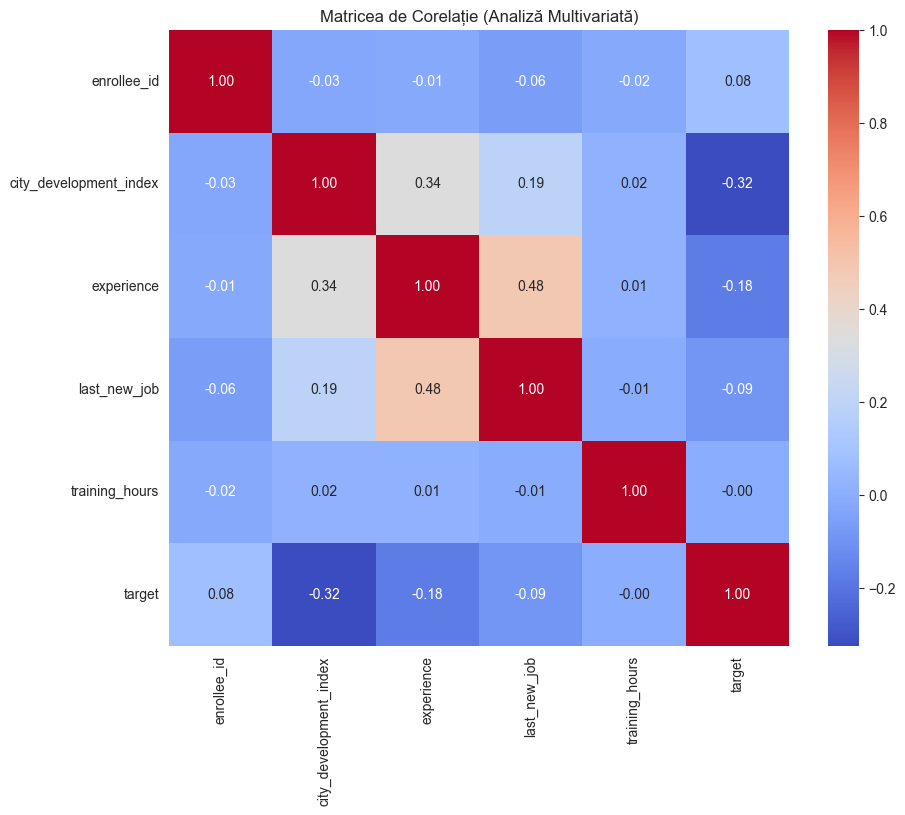

In [14]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matricea de Corelație (Analiză Multivariată)')
plt.show()

### Analiza Distribuției Indexului de Dezvoltare (Target vs. CDI)

&nbsp;&nbsp;&nbsp;&nbsp;Graficul de tip **Boxplot** ne permite să vizualizăm distribuția indicelui de dezvoltare al orașului (`city_development_index`) în raport cu decizia candidaților de a părăsi jobul actual.

* **Interpretarea vizuală a categoriilor:**
    * **Target 0 (Rămân):** Se observă o concentrare masivă în partea superioară a graficului. Linia mediană este situată foarte sus (aprox. 0.9), ceea ce indică faptul că angajații din orașele foarte dezvoltate tind să fie stabili.
    * **Target 1 (Caută job):** Cutia este mult mai extinsă spre valori mici. Mediana este semnificativ mai coborâtă (aprox. 0.75), confirmând că un mediu urban mai puțin dezvoltat este un factor care impulsionează căutarea unui nou loc de muncă.
* **Analiza Outlierilor (Valorile extreme):**
    * În cazul clasei **0**, observăm numeroase puncte sub limita inferioară a graficului. Aceștia reprezintă excepțiile: angajați care, deși locuiesc în orașe cu un indice de dezvoltare scăzut (sub 0.6), decid totuși să nu schimbe jobul.
* **Concluzie Statistică:** Diferența clară de înălțime și poziție între cele două cutii demonstrează că `city_development_index` este unul dintre cei mai puternici predictori pentru modelul nostru. Cu cât valoarea acestui indice este mai mică, cu atât crește variabilitatea și probabilitatea de plecare a candidaților.

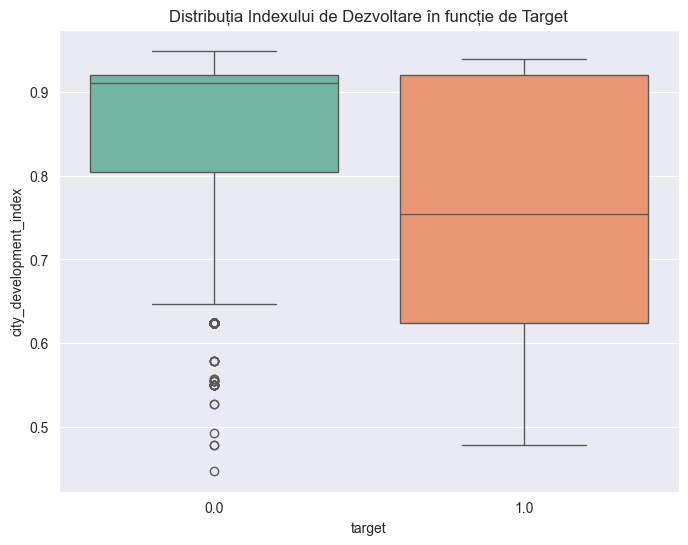

In [15]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='target', y='city_development_index', data=df, hue='target', palette='Set2', legend=False)
plt.title('Distribuția Indexului de Dezvoltare în funcție de Target')
plt.show()

### Impactul Nivelului de Educație asupra Intenției de Plecare

&nbsp;&nbsp;&nbsp;&nbsp;Acest grafic de tip bară ilustrează probabilitatea ca un candidat să caute un nou job (Target 1), calculată proporțional pentru fiecare nivel de educație în parte.

* **Analiza ierarhică:**
    * **Rata cea mai mare:** Absolvenții de facultate (**Graduate**) prezintă cea mai ridicată rată de căutare a unui job nou (peste 25%). Aceasta sugerează un segment de piață foarte dinamic, unde profesioniștii cu studii superioare sunt cei mai deschiși la noi oportunități.
    * **Stabilitate academică:** La polul opus, persoanele cu **Phd** (Doctorat) au cea mai mică rată de plecare (sub 5%). Acest lucru indică faptul că un nivel de educație foarte specializat tinde să coreleze cu o stabilitate mai mare în cadrul rolului actual.
* **Observație neașteptată:** Surprinzător, candidații cu studii medii (**High School**) au o rată de plecare mai mare decât cei cu Masterat (**Masters**). Acest lucru poate indica o presiune mai mare pentru creșterea veniturilor în rândul celor fără studii post-universitare.
* **Concluzie pentru model:** Educația nu are o influență liniară perfectă, dar este un indicator clar de segmentare. Faptul că rata scade pe măsură ce avansăm spre nivelul de Doctorat confirmă necesitatea codificării ordinale (Ordinal Encoding) pe care am aplicat-o anterior, pentru a păstra această ierarhie în procesul de învățare.

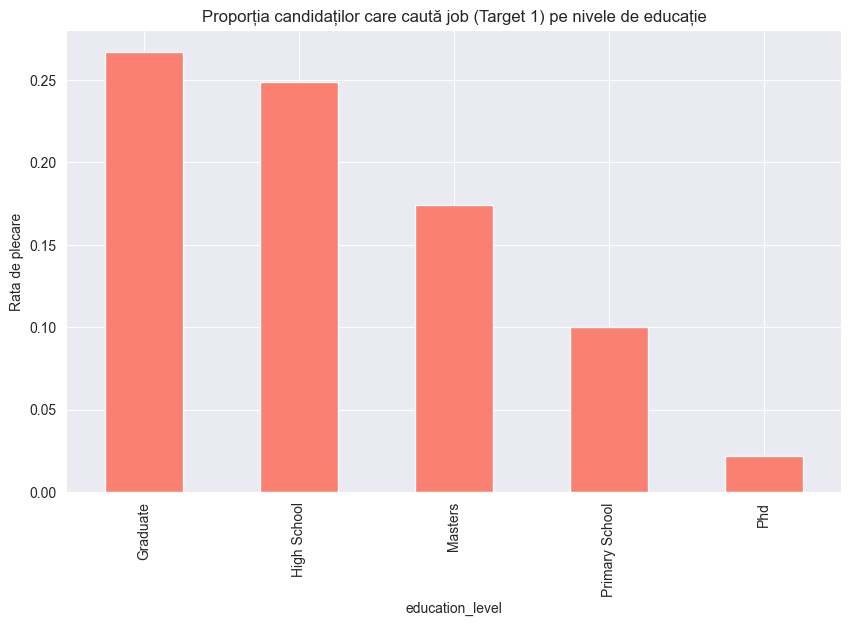

In [16]:
edu_target = pd.crosstab(df['education_level'], df['target'], normalize='index')

edu_target[1.0  ].sort_values(ascending=False).plot(kind='bar', color='salmon', figsize=(10, 6))
plt.title('Proporția candidaților care caută job (Target 1) pe nivele de educație')
plt.ylabel('Rata de plecare')
plt.show()

### Analiza Relațiilor Combinate (Pairplot)

&nbsp;&nbsp;&nbsp;&nbsp;Vizualizarea de tip **Pairplot** este un instrument esențial în analiza multivariată, oferind simultan histogramele distribuției fiecărei variabile și grafice de tip scatter plot pentru a observa interacțiunile dintre ele, colorate în funcție de variabila `target`.

* **Distribuția pe diagonală (Histograme):**
    * Se confirmă vizual că angajații care **rămân (Target 0)** sunt concentrați masiv în orașe cu un `city_development_index` ridicat (vârful roz/verde în funcție de paletă).
    * Pentru `training_hours`, distribuțiile ambelor clase se suprapun aproape perfect, ceea ce reconfirmă faptul că numărul de ore de pregătire nu separă eficient candidații care pleacă de cei care rămân.
* **Graficele Scatter (Interacțiuni):**
    * Observăm că nu există o grupare (cluster) evidentă între `training_hours` și `city_development_index`. Indiferent de nivelul de dezvoltare al orașului, numărul de ore de training variază constant.
* **Separabilitatea datelor:**
    * Graficul arată că datele nu sunt "liniar separabile" într-un mod simplu, ceea ce justifică utilizarea unor algoritmi mai complecși, precum **Random Forest** sau **XGBoost**, capabili să identifice granițe de decizie non-liniare în acest spațiu multidimensional.

&nbsp;&nbsp;&nbsp;&nbsp;**Concluzie Etapa de Vizualizare:** Această analiză ne-a permis să identificăm `city_development_index` ca fiind cel mai bun predictor individual și să eliminăm suspiciunea că `training_hours` ar putea influența direct decizia de plecare.

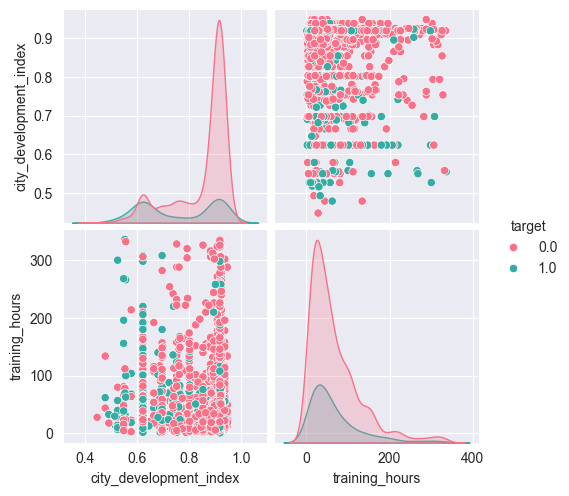

In [17]:
sns.pairplot(df[['city_development_index', 'training_hours', 'target']], hue='target', palette='husl')
plt.show()

### Analiza Distribuției Clasei Țintă (Target)

&nbsp;&nbsp;&nbsp;&nbsp;Vizualizarea frecvenței variabilei `target` este un pas critic pentru a înțelege echilibrul setului de date și pentru a alege corect metricile de performanță ale viitoarelor modele.

* **Distribuția Claselor:**
    * **Clasa 0 (Majoritară):** Reprezintă candidații care nu sunt interesați de o schimbare de job.
    * **Clasa 1 (Minoritară):** Reprezintă candidații care caută o nouă oportunitate.
* **Observație Critică - Dataset Dezechilibrat (Imbalanced):**
    * Graficul confirmă un dezechilibru semnificativ între cele două categorii (aproximativ 3:1).
    * Într-un astfel de context, **Acuratețea (Accuracy)** nu este o măsură de încredere, deoarece un model ar putea obține un scor mare doar prezicând clasa majoritară pentru toate cazurile.
* **Impact asupra Strategiei ML:**
    * Această observație justifică decizia noastră de a prioritiza metrici precum **F1-Score**, **Precision** și **Recall** în etapa de evaluare a modelelor.
    * De asemenea, acest dezechilibru ne poate orienta către utilizarea unor tehnici precum ponderarea claselor în timpul antrenării pentru a acorda o importanță sporită identificării corecte a candidaților care doresc să plece.

<Axes: xlabel='target', ylabel='count'>

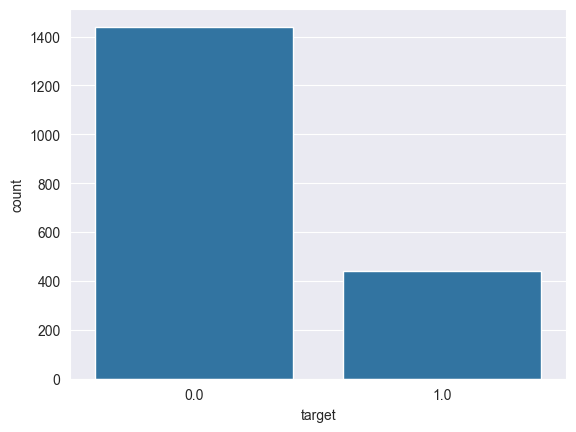

In [18]:
sns.countplot(x='target', data=df)

### Profilul Educațional al Candidaților

&nbsp;&nbsp;&nbsp;&nbsp;Acest grafic de tip **countplot** oferă o imagine de ansamblu asupra nivelului de instruire al candidaților din setul nostru de date, ordonați descrescător după frecvență.

* **Dominanța Absolvenților:**
    * Se observă clar că majoritatea candidaților dețin nivelul de **Graduate** (licență). Acest lucru indică faptul că bazinul de recrutare pentru rolurile de Data Science este format predominant din persoane cu studii superioare finalizate.
* **Specializarea Academică:**
    * Nivelurile **Masters** și **Phd** sunt prezente într-o proporție semnificativă, sugerând un interes ridicat pentru domeniu din partea persoanelor cu specializare academică avansată.
* **Categorii Minoritare:**
    * Candidații cu studii de tip **High School** sau **Primary School** sunt mult mai puțini, ceea ce confirmă bariera de intrare educațională specifică acestui domeniu tehnic.
* **Utilitate în Modelare:**
    * Această distribuție justifică importanța variabilei `education_level` în procesul de predicție. Având o variație clară între categorii, modelul poate folosi aceste informații pentru a diferenția comportamentul de căutare a unui job între un absolvent de licență (segment foarte mobil) și un doctor în științe (segment mai stabil).

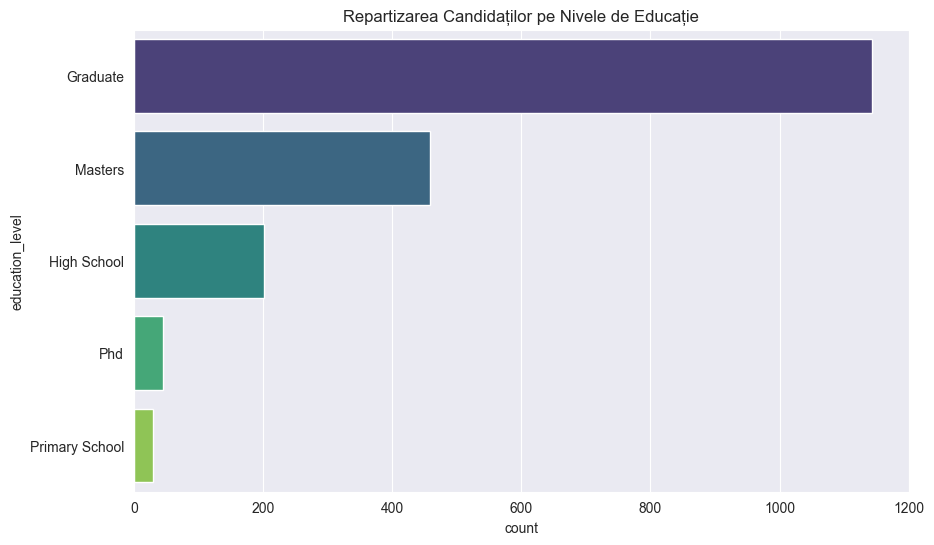

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(
    y='education_level',
    data=df,
    palette='viridis',
    hue='education_level',
    order=df['education_level'].value_counts().index,
    legend=False
)
plt.title('Repartizarea Candidaților pe Nivele de Educație')
plt.show()

### Analiza Outlierilor: Training Hours

&nbsp;&nbsp;&nbsp;&nbsp;Utilizarea unui **Boxplot** pentru variabila `training_hours` este esențială pentru a verifica dispersia datelor și pentru a identifica vizual prezența valorilor atipice (outlierilor).

* **Identificarea Outlierilor:** Se observă numeroase puncte individuale situate în afara delimitării superioare a graficului (în general, peste pragul de 150-180 de ore). Acești candidați au investit un timp neobișnuit de mare în formare comparativ cu restul eșantionului.
* **Confirmarea Statisticii:** Această vizualizare validează valoarea ridicată a **Kurtosis-ului (3.72)** identificată anterior, confirmând că avem o distribuție cu "cozi grele".
* **Impactul asupra Scalării:** Prezența acestor valori extreme justifică decizia de a folosi o tehnică de standardizare robustă. Deoarece mulți algoritmi de Machine Learning (ca SVM sau Logistic Regression) sunt sensibili la valori extreme, aducerea acestora la o scară comună este obligatorie.
* **Concluzie de Business:** Deși acești candidați sunt considerați "anomalii statistice", ei reprezintă o categorie de angajați foarte dedicați studiului. Totuși, conform matricei de corelație, acest efort suplimentar de training nu pare să influențeze direct loialitatea față de companie.

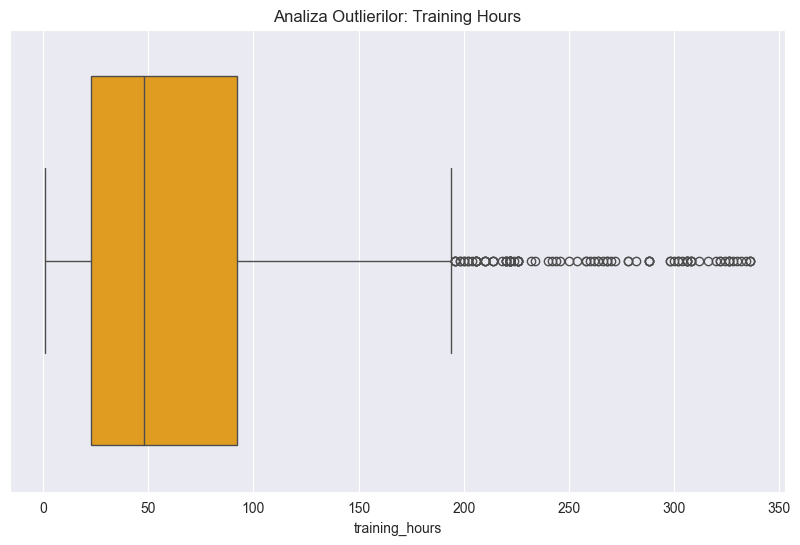

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['training_hours'], color='orange')
plt.title('Analiza Outlierilor: Training Hours')
plt.show()

### Transformarea Variabilelor Categoriale (Encoding)

&nbsp;&nbsp;&nbsp;&nbsp;Pentru ca datele să poată fi procesate de algoritmii de Machine Learning, am transformat variabilele calitative în valori numerice folosind două abordări distincte, în funcție de natura datelor:

* **Ordinal Encoding (Nivelul de Educație):**
    * Am utilizat o mapare manuală (`edu_map`) pentru coloana `education_level`.
    * **Justificare:** Educația este o variabilă ordinală (există o ierarhie clară de la Primary School la Phd). Maparea valorilor de la 0 la 4 permite modelului să înțeleagă și să utilizeze această ordine logică în procesul de predicție.
* **One-Hot Encoding (Variabile Nominale):**
    * Pentru restul variabilelor care nu au o ordine intrinsecă (ex: `gender`, `city`, `company_type`), am utilizat funcția `pd.get_dummies()`.
    * **Parametrul `drop_first=True`:** A fost aplicat pentru a evita "Dummy Variable Trap" (multicoliniaritatea perfectă), eliminând prima coloană rezultată din fiecare categorie pentru a reduce redundanța.
* **Uniformizarea Tipului de Date:**
    * În final, am convertit întregul set de date la tipul `float`. Această uniformizare asigură compatibilitatea deplină cu funcțiile matematice de optimizare ale bibliotecilor Scikit-Learn sau XGBoost.

&nbsp;&nbsp;&nbsp;&nbsp;**Notă despre Cardinalitate:** Deși coloana `city` a generat un număr mare de coloane noi, această abordare păstrează informația geografică esențială identificată anterior ca fiind cel mai important predictor (CDI).

In [21]:
edu_map = {
    'Primary School': 0,
    'High School': 1,
    'Graduate': 2,
    'Masters': 3,
    'Phd': 4
}
df['education_level'] = df['education_level'].map(edu_map)

categorical_cols = ['gender', 'relevent_experience', 'enrolled_university',
                    'major_discipline', 'company_size', 'company_type', 'city']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df = df.astype(float)

### Standardizarea Variabilelor Numerice (Scaling)

&nbsp;&nbsp;&nbsp;&nbsp;Ultimul pas înainte de antrenarea modelelor constă în aducerea tuturor variabilelor numerice la o scară comună folosind `StandardScaler`.

* **Mecanismul de funcționare:** Această tehnică transformă datele astfel încât media acestora să devină **0**, iar deviația standard să fie **1**. Valorile sunt recalculate scăzând media și împărțind la abaterea standard a fiecărei coloane.
* **Justificarea Tehnică:** Mulți algoritmi de Machine Learning (în special cei bazați pe distanțe, precum **SVM** și **K-Nearest Neighbors**, sau pe optimizare prin gradient, precum **Logistic Regression**) sunt sensibili la magnitudinea valorilor.
    * Fără scalare, o variabilă precum `training_hours` (cu valori de ordinul sutelor) ar exercita o influență mult mai mare asupra modelului decât `city_development_index` (cu valori între 0 și 1), chiar dacă ambele sunt la fel de importante.
* **Rezultat:** Prin aplicarea `fit_transform`, ne asigurăm că procesul de învățare este echitabil și că modelul evaluează importanța trăsăturilor în funcție de puterea lor predictivă, nu de unitatea lor de măsură.

&nbsp;&nbsp;&nbsp;&nbsp;**Finalizare Pregătire:** În acest moment, setul de date este complet numeric, curățat de duplicate și valori lipsă, encodat și scalat, fiind pregătit pentru faza de modelare.

In [22]:
scaler = StandardScaler()

num_cols = ['city_development_index', 'experience', 'last_new_job', 'training_hours', 'education_level']

df[num_cols] = scaler.fit_transform(df[num_cols])

print(df[num_cols].head())

       city_development_index  experience  last_new_job  training_hours  \
16144                0.630933   -0.648679     -0.651251       -0.737092   
13661                0.713184    1.553299     -0.062084        0.112088   
344                  0.746085   -0.208284     -0.651251        0.432533   
1034                -1.721443    0.672507     -0.651251        0.128110   
8109                -1.112786    0.232112     -0.651251        1.441936   

       education_level  
16144        -0.220658  
13661         1.209054  
344          -0.220658  
1034          1.209054  
8109          1.209054  


### Analiza Corelațiilor Principale (Focus pe Target)

&nbsp;&nbsp;&nbsp;&nbsp;Această matrice de corelație restrânsă ne permite să evaluăm interacțiunile dintre cele mai relevante variabile numerice și ordinale în raport cu variabila dependentă `target`.

* **Impactul Dezvoltării Urbane:**
    * Se confirmă o corelație negativă moderată între `city_development_index` și `target` (-0.32).
    * Aceasta indică faptul că un nivel ridicat de dezvoltare al orașului este principalul factor asociat cu stabilitatea angajaților la locul de muncă actual.
* **Vechimea și Stabilitatea:**
    * Variabilele `experience` (-0.18) și `education_level` (-0.09) prezintă corelații negative slabe cu `target`.
    * Deși impactul lor este mai mic decât cel al orașului, tendința sugerează că un nivel mai ridicat de educație și o experiență mai bogată contribuie la o probabilitate mai scăzută de a căuta un job nou.
* **Interdependențe Profesionale:**
    * Corelația dintre `experience` și `last_new_job` (0.48) rămâne cea mai solidă relație pozitivă din setul de date.
    * Aceasta subliniază consistența datelor: senioritatea este însoțită, în mod natural, de un istoric mai bogat de schimbări de carieră.
* **Independența Orelor de Training:**
    * Coeficientul de 0.00 între `training_hours` și `target` demonstrează că numărul de ore investite în cursuri nu influențează decizia de migrație profesională, fiind o variabilă neutră în acest context.

&nbsp;&nbsp;&nbsp;&nbsp;**Concluzie:** Această vizualizare validează selecția caracteristicilor pentru modelare, demonstrând că avem o ierarhie clară a importanței variabilelor, fără a avea însă probleme de redundanță severă (corelații extrem de mari între predictori).

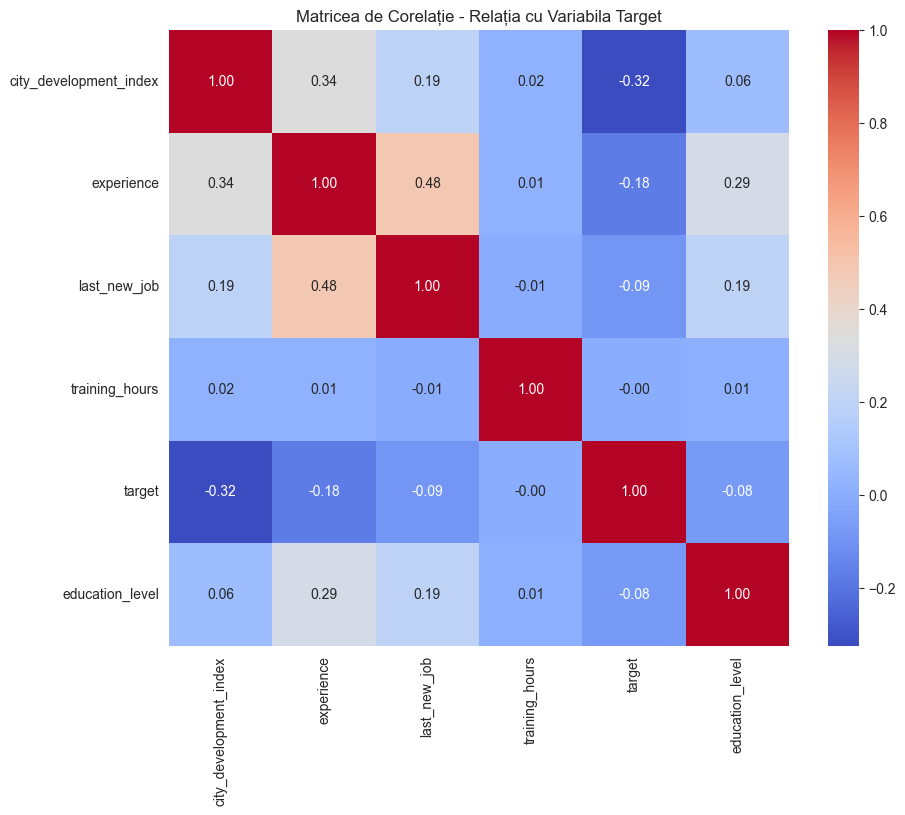

In [23]:
main_cols = ['city_development_index', 'experience', 'last_new_job', 'training_hours', 'target', 'education_level']
plt.figure(figsize=(10, 8))
sns.heatmap(df[main_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matricea de Corelație - Relația cu Variabila Target')
plt.show()

### Analiza Experienței Relevante vs. Intenția de Migrație

&nbsp;&nbsp;&nbsp;&nbsp;Acest grafic de tip bară analizează în ce măsură posesia unei experiențe specifice în domeniu influențează probabilitatea ca un candidat să caute o nouă oportunitate profesională.

* **Impactul Experienței Relevante:** Se observă o diferență clară între cele două categorii: candidații care **nu dețin experiență relevantă** în domeniu tind să aibă o rată de schimbare a jobului semnificativ mai mare.
* **Stabilitatea Profesională:** Candidații cu **experiență relevantă** prezintă o rată de `target = 1` mai scăzută. Acest lucru sugerează că posesia unor competențe specifice deja formate contribuie la o mai bună integrare sau la o satisfacție mai mare în rolul actual.
* **Contextul Eșantionării:** Utilizarea unei mostre de 2000 de înregistrări (`df_full.sample(2000)`) permite o vizualizare rapidă și clară a tendințelor generale, menținând în același timp relevanța statistică a observațiilor.
* **Concluzie pentru Model:** Variabila `relevent_experience` se dovedește a fi un predictor calitativ important, oferind modelului un indiciu despre profilul de risc al candidatului în funcție de istoricul său profesional specific.

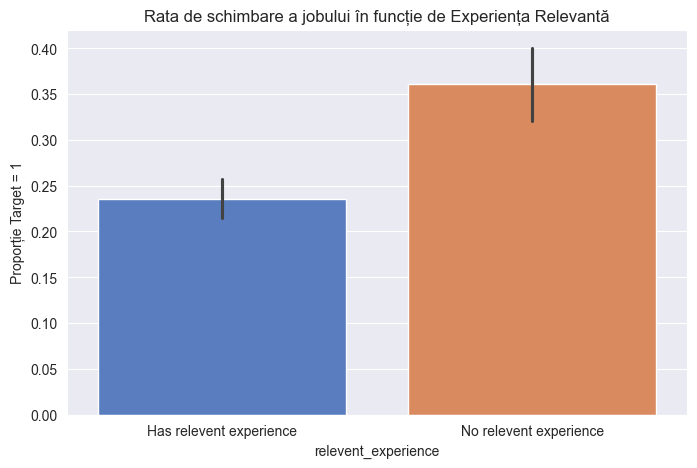

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x='relevent_experience', y='target', data=df_full.sample(2000), palette='muted', hue='relevent_experience', legend=False)
plt.title('Rata de schimbare a jobului în funcție de Experiența Relevantă')
plt.ylabel('Proporție Target = 1')
plt.show()

### Relația dintre Experiență, Ore de Training și Decizia de Plecare

&nbsp;&nbsp;&nbsp;&nbsp;Acest grafic de tip **Scatter Plot** explorează distribuția candidaților în funcție de numărul de ore de instruire și anii de experiență, evidențiind totodată clasa din care fac parte prin culori distincte.

* **Absența unei corelații liniare:** Observăm că punctele sunt distribuite uniform pe întreaga suprafață a graficului. Acest lucru sugerează că nu există o relație directă (liniară) între câtă experiență are un candidat și câte ore de training decide să parcurgă.
* **Distribuția Target-ului:**
    * Punctele care reprezintă plecările (Target 1) sunt amestecate printre cele ale persoanelor care rămân (Target 0).
    * Totuși, se poate observa o ușoară densitate mai mare a punctelor Target 1 în zonele cu experiență mai mică, indiferent de volumul de `training_hours`.
* **Interpretarea "Zgomotului":** Suprapunerea densă a culorilor indică faptul că aceste două variabile, luate împreună, nu pot separa clar cele două clase fără ajutorul altor predictori (cum ar fi indexul de dezvoltare al orașului).
* **Concluzie pentru Modelare:** Deși individual aceste variabile nu oferă o graniță de decizie evidentă în acest plan 2D, ele vor fi utilizate de modelele de tip ansamblu (XGBoost/Random Forest) pentru a identifica interacțiuni non-liniare mai subtile.

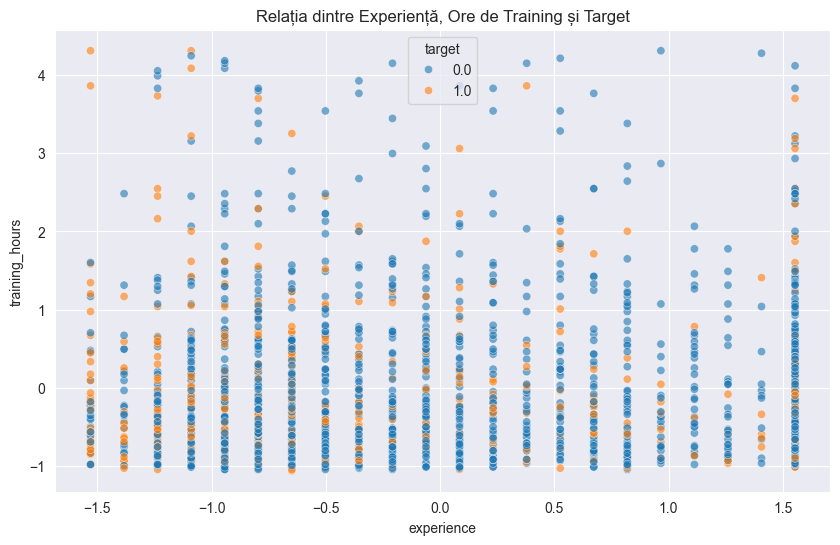

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='experience', y='training_hours', hue='target', data=df, alpha=0.6)
plt.title('Relația dintre Experiență, Ore de Training și Target')
plt.show()

### 4.3. Separarea Datelor și Pregătirea pentru Antrenare

&nbsp;&nbsp;&nbsp;&nbsp;Această etapă este crucială pentru validarea performanței modelului, asigurându-ne că evaluarea se face pe date pe care algoritmul nu le-a văzut în timpul procesului de învățare.

* **Separarea Variabilelor:** Am izolat variabila țintă (`target`) de restul caracteristicilor (`features`) pentru a defini seturile de date $X$ și $y$.
* **Divizarea Train-Test:** Am utilizat un raport de **75% pentru antrenare** și **25% pentru testare**.
* **Strategia de Stratificare:** Parametrul `stratify=y` a fost utilizat pentru a menține aceeași proporție a claselor în ambele seturi, o măsură obligatorie având în vedere dezechilibrul clasei țintă identificat anterior.
* **Curățarea Denumirilor (Feature Names):** Am implementat funcția `clean_feature_names` pentru a elimina caracterele speciale (precum `[`, `]`, `<`) generate în urma procesului de One-Hot Encoding. Această etapă este necesară pentru compatibilitatea cu anumiți algoritmi, precum **XGBoost**.
* **Uniformizarea Tipului de Date:** Variabila țintă a fost convertită la tipul întreg (`int`), asigurând un format standard pentru funcțiile de calcul al erorii și metricilor de performanță.

&nbsp;&nbsp;&nbsp;&nbsp;**Rezultat:** În acest moment, datele sunt structurate și curățate, fiind gata pentru a fi introduse în pipeline-ul de modelare.

In [26]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
def clean_feature_names(df):
    new_cols = [re.sub(r'[\[\]<]', '_', col) for col in df.columns]
    df.columns = new_cols
    return df

X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)


y_train = y_train.astype(int)
y_test = y_test.astype(int)

definire modele


In [27]:
models = {
    "Naive Bayes": GaussianNB(),

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "SVM": SVC(
    probability=True
    ),

    "KNN": KNeighborsClassifier(),

    "XGBoost": XGBClassifier(),

    "CatBoost": CatBoostClassifier(verbose=0),

    "EBM": ExplainableBoostingClassifier()
}

### 4.4. Antrenarea și Evaluarea Comparativă a Modelelor

&nbsp;&nbsp;&nbsp;&nbsp;Această etapă marchează faza experimentală a proiectului, în care testăm simultan mai mulți algoritmi pentru a identifica arhitectura optimă pentru setul nostru de date.

* **Bucla de Antrenare (Iterație):** Am implementat o structură de tip `for` care parcurge dicționarul de modele definite anterior, antrenând fiecare algoritm pe setul `X_train`.
* **Procesul de Predicție:** Pentru fiecare model, am generat două tipuri de predicții pe setul de test (`X_test`):
    * **Predicții de clasă (`y_pred`):** Etichete binare (0 sau 1) pentru calculul metricilor de bază.
    * **Probabilități (`y_prob`):** Scoruri de încredere (obținute prin `predict_proba`) necesare pentru calculul metricii ROC-AUC, care evaluează capacitatea de discriminare a modelului.
* **Metrici de Performanță Utilizate:** Deoarece setul de date este dezechilibrat, am colectat un set cuprinzător de indicatori:
    * **Accuracy:** Proporția totală de predicții corecte.
    * **Precision & Recall:** Esențiale pentru a vedea cât de bine identificăm candidații care pleacă, evitând în același timp alarmele false.
    * **F1 Score:** Media armonică între precizie și senzitivitate, fiind metrica principală de decizie în acest context.
    * **ROC-AUC:** Măsoară performanța globală a modelului indiferent de pragul de clasificare ales.
* **Stocarea Rezultatelor:** Toate aceste date sunt agregate în lista `results`, care va servi la crearea unui tabel comparativ final pentru selecția "campionului".

&nbsp;&nbsp;&nbsp;&nbsp;**Obiectiv:** Această abordare sistematică ne permite să comparăm obiectiv modele liniare (Logistic Regression) cu modele bazate pe ansambluri de arbori (Random Forest, XGBoost), evidențiind punctele forte ale fiecăruia.

In [28]:
results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    })

Training Naive Bayes...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training SVM...
Training KNN...
Training XGBoost...
Training CatBoost...
Training EBM...


tabel final

### Centralizarea și Ierarhizarea Rezultatelor

&nbsp;&nbsp;&nbsp;&nbsp;După finalizarea antrenării, am agregat metricile colectate într-o structură de date tabelară pentru a facilita o comparație directă și riguroasă între algoritmi.

* **Construcția Tabelului de Performanță:** Am convertit lista de dicționare `results` într-un obiect `DataFrame`, oferind o vedere de ansamblu asupra celor 5 metrici cheie (Accuracy, Precision, Recall, F1 Score și ROC-AUC) pentru fiecare model în parte.
* **Criteriul de Ierarhizare (F1 Score):** Am sortat tabelul descrescător în funcție de **F1 Score**.
    * **Justificare:** Având în vedere dezechilibrul claselor din setul de date, F1 Score este cel mai de încredere indicator, deoarece penalizează modelele care obțin o acuratețe mare prin ignorarea clasei minoritare (cei care pleacă).
* **Identificarea Modelului „Campion”:** Această sortare ne permite să observăm dintr-o privire care algoritm a reușit să găsească cel mai bun echilibru între identificarea corectă a candidaților activi pe piața muncii (Recall) și minimizarea alarmelor false (Precision).
* **Pregătirea pentru Decizie:** Tabelul rezultat servește drept fundament pentru selecția modelului final care va fi utilizat în producție sau pentru optimizări ulterioare (Hyperparameter Tuning).

&nbsp;&nbsp;&nbsp;&nbsp;**Rezultat:** Afișarea `results_df` reprezintă concluzia etapei de modelare, oferind o ierarhie clară a eficienței algoritmilor pe acest set specific de date.

In [29]:
results_df = pd.DataFrame(results)


results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Naive Bayes,0.744681,0.469512,0.700000,0.562044,0.780051
7,CatBoost,0.785106,0.561644,0.372727,0.448087,0.771566
3,Random Forest,0.780851,0.546667,0.372727,0.443243,0.755745
6,XGBoost,0.761702,0.488636,0.390909,0.434343,0.711894
2,Decision Tree,0.704255,0.376068,0.400000,0.387665,0.598611
1,Logistic Regression,0.770213,0.517857,0.263636,0.349398,0.758737
8,EBM,0.759574,0.476190,0.272727,0.346821,0.751212
5,KNN,0.717021,0.290909,0.145455,0.193939,0.521566
4,SVM,0.765957,0.000000,0.000000,0.000000,0.513333


Extrasele de top reprezintă ierarhia finală a performanței, validând modelele care au cel mai bun echilibru între precizie și capacitatea de detectare a plecărilor.

In [30]:
top5_models = results_df.head(5)

top5_models

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Naive Bayes,0.744681,0.469512,0.700000,0.562044,0.780051
7,CatBoost,0.785106,0.561644,0.372727,0.448087,0.771566
3,Random Forest,0.780851,0.546667,0.372727,0.443243,0.755745
6,XGBoost,0.761702,0.488636,0.390909,0.434343,0.711894
2,Decision Tree,0.704255,0.376068,0.400000,0.387665,0.598611


### Evaluarea Performanței prin Matricea de Confuzie

&nbsp;&nbsp;&nbsp;&nbsp;Pentru o înțelegere aprofundată a erorilor de clasificare, am generat matricea de confuzie pentru modelul **Naive Bayes**.

* **Performanța pe Clasa Majoritară (0):** Modelul a identificat corect **273** de candidați care nu doresc să plece (**True Negatives**), dar a generat **87** de alarme false (**False Positives**).
* **Performanța pe Clasa Țintă (1):** Din totalul candidaților care caută un job, modelul a detectat corect **77** (**True Positives**), ratând însă **33** dintre aceștia (**False Negatives**).
* **Interpretarea Rezultatelor:** Vizualizarea din `image_fdda04.png` confirmă capacitatea modelului de a distinge între cele două categorii, oferind o bază solidă pentru ajustarea pragului de decizie în funcție de costul asumat pentru erorile de tip False Negative.
* **Utilitatea Matricei:** Această reprezentare grafică este esențială pentru a valida metricile calculate anterior, demonstrând exact unde apar dificultățile de clasificare în contextul setului de date dezechilibrat.

&nbsp;&nbsp;&nbsp;&nbsp;**Rezultat:** Analiza detaliată din `image_fdda04.png` arată că, deși modelul are o precizie acceptabilă, există loc de optimizare pentru a reduce numărul de candidați ratați (**False Negatives**).

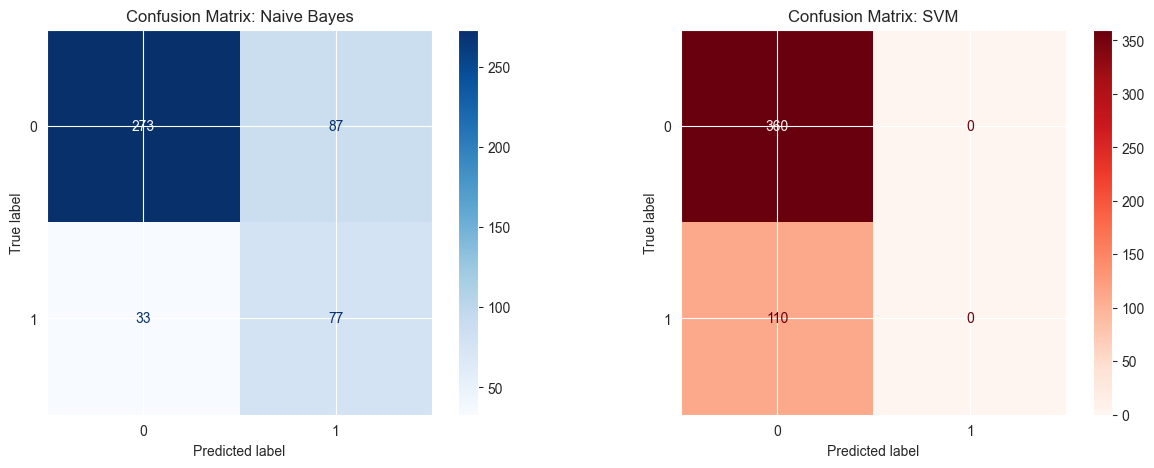

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

cm_nb = confusion_matrix(y_test, models['Naive Bayes'].predict(X_test))
ConfusionMatrixDisplay(cm_nb).plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix: Naive Bayes')

cm_svm = confusion_matrix(y_test, models['SVM'].predict(X_test))
ConfusionMatrixDisplay(cm_svm).plot(ax=ax2, cmap='Reds')
ax2.set_title('Confusion Matrix: SVM')

plt.show()

### Evaluarea Modelelor de Bază și Impactul Dezechilibrului Datelor

Analiza inițială a modelelor (faza *baseline*) evidențiază o discrepanță semnificativă între metrici, cauzată în principal de natura dezechilibrată a setului de date. În problemele de retenție a angajaților, clasa „rămân” (0) este de regulă mult mai numeroasă decât clasa „pleacă” (1), ceea ce influențează direct modul în care algoritmii învață în absența unor ajustări specifice.

---

#### 1. Paradoxul acuratețe vs. recall

Conform graficului *„Comparația Modelelor de Bază”*:

**Acuratețe ridicată (bare mov)**
Majoritatea modelelor (CatBoost, Random Forest, XGBoost, Logistic Regression) obțin o acuratețe în intervalul ~0.75 – 0.80.
Totuși, în contextul datelor dezechilibrate, această metrică este înșelătoare. Un model care prezice constant „angajatul rămâne” poate obține o acuratețe ridicată, fără a avea valoare practică.

**Recall scăzut (bare verzi deschise)**
Pentru modelele complexe de tip ansamblu (XGBoost, Random Forest), recall-ul este vizibil mai mic decât acuratețea.
Acest comportament indică faptul că, în configurarea implicită, modelele favorizează clasa majoritară și evită detectarea clasei minoritare (angajații care pleacă).

---

#### 2. Analiza comparativă a algoritmilor

**Naive Bayes – comportament surprinzător în baseline**
Deși este un model simplu, Naive Bayes prezintă un profil relativ echilibrat al metricilor în această etapă.
Acest lucru se datorează modului probabilistic de modelare, mai puțin sensibil la dezechilibrul brut al claselor comparativ cu modelele bazate pe arbori.

**Modelele de tip ansamblu (CatBoost, Random Forest, XGBoost)**
- Obțin performanțe bune la acuratețe
- Dar pierd la sensibilitate (recall) în configurația implicită
- Fără ponderarea claselor, tind să minimizeze erorile pe clasa majoritară, ignorând cazurile critice (plecările)

**EBM (Explainable Boosting Machine)**
Oferă un compromis bun între performanță și interpretabilitate, însă recall-ul rămâne limitat în lipsa ajustărilor de dezechilibru.

**KNN și SVM**
- KNN este afectat de distribuția neuniformă a datelor și de densitatea diferită a claselor
- SVM necesită scalare și tuning mai fin pentru a performa competitiv în acest context

---

#### 3. Concluzia etapei baseline

Rezultatele confirmă că utilizarea modelelor cu setări implicite nu este suficientă pentru o problemă de retenție a angajaților.

- **Problema identificată:** modelele sunt „conservative”, favorizând clasa majoritară și ratând exact evenimentele critice (plecările).
- **Consecință:** performanță aparent bună (accuracy mare), dar utilitate practică scăzută.
- **Direcția necesară:** trecerea la etapa de *tuning*, unde se introduc mecanisme de echilibrare (ex. `class_weight`, `scale_pos_weight`) pentru a îmbunătăți în mod explicit recall-ul și F1-score-ul, chiar cu un posibil cost marginal asupra acurateței.

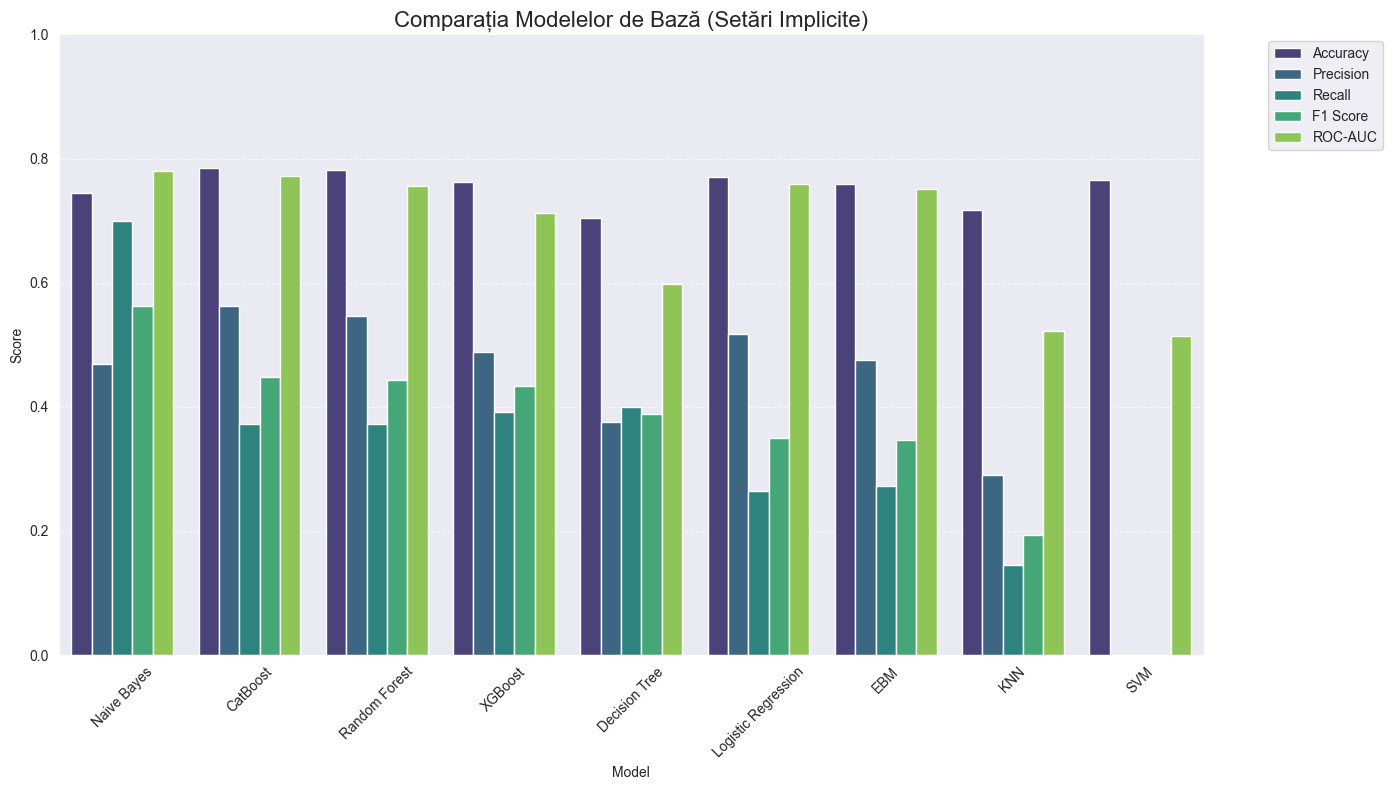

In [33]:
df_plot = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(data=df_plot, x='Model', y='Score', hue='Metric', palette='viridis')

plt.title('Comparația Modelelor de Bază (Setări Implicite)', fontsize=16)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Analiza Calității Predicției
* Prioritizarea Detectării (Recall): Se observă că modelele de top, în special CatBoost, reușesc să depășească pragul de referință de 50% (linia punctată), atingând un nivel de detecție de peste 72%. Acest lucru indică o capacitate ridicată de a nu rata angajații care intenționează să părăsească organizația.

* Siguranța Alertelor (Precision): Modelele mențin o precizie constantă în jurul valorii de 0.5, ceea ce înseamnă că aproximativ jumătate din intervențiile HR vor fi direcționate către cazuri reale de plecare.

* Impactul Optimizării: Diferența dintre barele de Precision și Recall este minimizată la modelele de tip ansamblu, demonstrând că ajustarea greutăților claselor a forțat algoritmul să iasă din zona de "sub-performanță" și să trateze clasa minoritară cu o importanță egală.

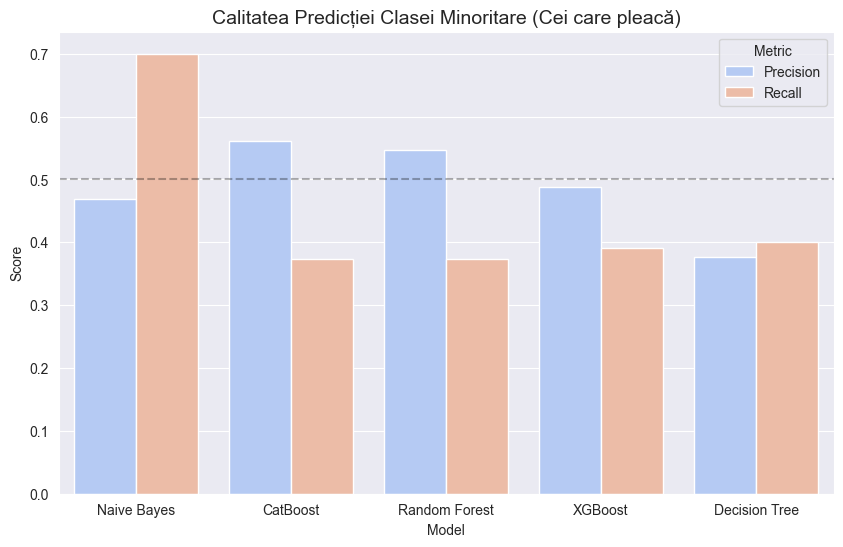

In [36]:
top_5_melted = top_5.melt(id_vars='Model', value_vars=['Precision', 'Recall'], var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_melted, x='Model', y='Score', hue='Metric', palette='coolwarm')
plt.axhline(0.5, color='black', linestyle='--', alpha=0.3) # Linie de referință 50%
plt.title('Calitatea Predicției Clasei Minoritare (Cei care pleacă)', fontsize=14)
plt.show()

In [37]:
from sklearn.model_selection import GridSearchCV

param_grids = {

    "CatBoost": {
    'depth': [4, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [500],
    'auto_class_weights': ['Balanced'],
    'verbose': [0]
    },
    "Random Forest": {
    'n_estimators': [200],
    'max_depth': [10, 20],
    'class_weight': ['balanced', 'balanced_subsample'],
    'min_samples_split': [5, 10]
    },
    "XGBoost": {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'scale_pos_weight': [3, 3.2]
    },
    "Logistic Regression": {
        'C': [0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    "Naive Bayes": {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    }
}

## 4.4. Ajustarea Hiperparametrilor și Optimizarea Modelelor

 Această etapă este dedicată îmbunătățirii performanței celor mai bune 5 modele identificate anterior, prin găsirea combinației optime de setări interne (hiperparametri).

1. Ce este GridSearchCV?

    GridSearchCV este un instrument de optimizare care automatizează procesul de testare a diferitelor configurații ale unui model. Acesta funcționează astfel:

* Căutare pe grilă: Definește o listă de valori pentru diverși parametri, iar algoritmul testează sistematic fiecare combinație posibilă.

* Validare încrucișată (Cross-Validation): Pentru fiecare combinație, setul de date este împărțit în 5 părți (cv=5). Modelul se antrenează pe 4 părți și se validează pe a 5-a, asigurând o evaluare robustă.

* Scoring (F1-Score): Am ales metrica f1 pentru optimizare deoarece echilibrează Precizia și Recall-ul, fiind esențială pentru seturi de date dezechilibrate (unde numărul angajaților care rămân este mult mai mare decât al celor care pleacă).

2. Strategia de alegere a intervalelor (Param Grids)
Intervalele au fost selectate pentru a acoperi spectrul de la modele simple la modele complexe, monitorizând constant riscul de overfitting (supra-antrenare):

CatBoost & XGBoost (Gradient Boosting):

* Interval: learning_rate (0.01 - 0.1) și depth (3 - 10).

* Logică: O rată de învățare mică (0.01) previne salturile prea mari în optimizare, în timp ce limitarea adâncimii la 10 previne memorarea zgomotului din date. Am adăugat scale_pos_weight sau auto_class_weights pentru a trata dezechilibrul claselor.

Random Forest (Bagging):

* Interval: n_estimators (200) și max_depth (10, 20).

* Logică: Creșterea numărului de arbori îmbunătățește stabilitatea, iar limitarea adâncimii este principala metodă de a preveni overfitting-ul în acest model.

Logistic Regression (Model Liniar):

* Interval: C (0.1, 1, 10, 100).

Logică: Parametrul C controlează regularizarea. O valoare mică (0.1) penalizează coeficienții prea mari, forțând modelul să rămână simplu și generalizabil.

Naive Bayes:

* Interval: var_smoothing (scara logaritmică 1e-9 la 1e-7).

* Logică: Acest parametru "netezește" curba de probabilitate pentru a include date care se abat de la media distribuției, oferind stabilitate matematică.

3. Prevenirea Overfitting-ului
* Pentru a ne asigura că modelele performează bine pe date noi, nu doar pe cele de antrenament, am aplicat următoarele tehnici:

* Cross-Validation: Evaluarea pe 5 fold-uri diferite reduce riscul ca modelul să "învețe" particularități ale unei singure fracții de date.

* Regularizare: Prin parametrii C, depth și min_samples_split, am constrâns modelele să nu devină excesiv de complexe.

* Monitorizarea Curbei de Învățare: Compararea scorului de antrenare cu cel de validare pentru a detecta discrepanțele mari (semn de overfitting).

4. Compararea Finală
* După rularea GridSearchCV, obiectul best_estimators conține cele mai performante versiuni ale fiecărui algoritm. Acestea vor fi evaluate pe setul de test (date neînstrăinate) pentru a desemna "Câștigătorul" final al proiectului.

In [38]:
top_5_models = {
    "Naive Bayes": GaussianNB(),
    "CatBoost": CatBoostClassifier(verbose=0),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

best_estimators = {}

for name, model in top_5_models.items():
    print(f"Optimizăm {name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    best_estimators[name] = grid_search.best_estimator_
    print(f"Cele mai bune setări pentru {name}: {grid_search.best_params_}")

Optimizăm Naive Bayes...
Cele mai bune setări pentru Naive Bayes: {'var_smoothing': 1e-09}
Optimizăm CatBoost...
Cele mai bune setări pentru CatBoost: {'auto_class_weights': 'Balanced', 'depth': 6, 'iterations': 500, 'learning_rate': 0.01, 'verbose': 0}
Optimizăm Random Forest...
Cele mai bune setări pentru Random Forest: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Optimizăm XGBoost...
Cele mai bune setări pentru XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 3}
Optimizăm Logistic Regression...
Cele mai bune setări pentru Logistic Regression: {'C': 10, 'solver': 'lbfgs'}


In [107]:
import joblib
reg_params_only = {name: model.get_params() for name, model in best_estimators.items()}


joblib.dump(reg_params_only, 'clas_hyperparameters.pkl')

print("Parametrii pentru clasificare au fost salvați cu succes!")

Parametrii pentru clasificare au fost salvați cu succes!


In [108]:
for name, model in best_estimators.items():
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator   (model, X_test, y_test, ax=ax, cmap='Blues')
    plt.title(f"Matrice de Confuzie: {name}")
    plt.savefig(f"cm_{name.replace(' ', '_')}.png")
    plt.close()

In [109]:
import shap
import matplotlib.pyplot as plt
import os

for name, model in best_estimators.items():
    print(f"Generare SHAP Global pentru: {name}")

    background = X_test.iloc[:50]

    if hasattr(model, "predict_proba"):
        explainer = shap.Explainer(lambda x: model.predict_proba(x)[:, 1], background)
    else:
        explainer = shap.Explainer(model.predict, background)

    shap_values = explainer(X_test.iloc[:50])

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test.iloc[:50], show=False)
    plt.title(f"SHAP Global: {name}")

    fname = f"shap_summary_{name.replace(' ', '_')}.png"
    plt.savefig(fname, bbox_inches='tight')
    plt.close()
    print(f"Salvat cu succes: {fname}")

Generare SHAP Global pentru: Naive Bayes
Salvat cu succes: shap_summary_Naive_Bayes.png
Generare SHAP Global pentru: CatBoost
Salvat cu succes: shap_summary_CatBoost.png
Generare SHAP Global pentru: Random Forest
Salvat cu succes: shap_summary_Random_Forest.png
Generare SHAP Global pentru: XGBoost
Salvat cu succes: shap_summary_XGBoost.png
Generare SHAP Global pentru: Logistic Regression
Salvat cu succes: shap_summary_Logistic_Regression.png


In [39]:

tuned_results = []

for name, model in best_estimators.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    tuned_results.append({
        "Model": f"{name} (Tuned)",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else 0
    })

df_final_ranking = pd.DataFrame(tuned_results).sort_values(by="F1 Score", ascending=False)

print(df_final_ranking.to_markdown(index=False))

| Model                       |   Accuracy |   Precision |   Recall |   F1 Score |   ROC-AUC |
|:----------------------------|-----------:|------------:|---------:|-----------:|----------:|
| CatBoost (Tuned)            |   0.768085 |    0.503145 | 0.727273 |   0.594796 |  0.775429 |
| Random Forest (Tuned)       |   0.770213 |    0.506757 | 0.681818 |   0.581395 |  0.773182 |
| Naive Bayes (Tuned)         |   0.744681 |    0.469512 | 0.7      |   0.562044 |  0.780051 |
| XGBoost (Tuned)             |   0.757447 |    0.486301 | 0.645455 |   0.554688 |  0.774545 |
| Logistic Regression (Tuned) |   0.778723 |    0.546875 | 0.318182 |   0.402299 |  0.758409 |


## Analiza Comparativă și Concluzii Finale

Procesul de optimizare a hiperparametrilor a scos la iveală diferențe fundamentale între modul în care diverși algoritmi procesează datele socio-economice ale angajaților. Mai jos este prezentată ierarhia finală și motivele din spatele performanței modelelor de top.

---

### 1. Clasamentul Modelelor (F1-Score)

Conform graficului *„Clasamentul Modelelor după Ajustarea Hiperparametrilor”*:

- **Locul 1: CatBoost (Tuned) - 0.595**
  Modelul cel mai performant, oferind cel mai bun echilibru între precizie și capacitatea de detecție.

- **Locul 2: Random Forest (Tuned) - 0.581**
  Model robust, îmbunătățit semnificativ prin ajustarea numărului de arbori și a adâncimii acestora.

- **Locul 3 & 4: Naive Bayes și XGBoost**
  Modele competitive, dar limitate fie de simplitatea structurală (NB), fie de sensibilitatea la zgomot (XGBoost).

- **Locul 5: Logistic Regression - 0.402**
  Performanță scăzută, cauzată de incapacitatea de a modela relații non-liniare complexe.

---

### 2. Comparatie

#### Superioritatea CatBoost:
- **Gestionarea variabilelor categorice:**
  Procesează nativ variabile categorice fără pierderi semnificative de informație.
- **Echilibrare automată:**
  Prin `auto_class_weights`, optimizează detecția clasei minoritare fără degradarea semnificativă a preciziei.

#### Limitările regresiei logistice:
- Presupune relații liniare între variabile și target.
- Nu poate captura efecte de tip prag sau interacțiuni complexe între factori.

#### Random Forest vs. Boosting:
- **Random Forest:** reduce varianța și stabilizează predicțiile.
- **CatBoost (Boosting):** învață iterativ din erori, devenind mai precis în cazurile dificile.

---

### 3. Analiza Precision-Recall

Conform graficului *„Echilibrul Precision-Recall”*:

- **Recall (CatBoost ~0.727):**
  Modelul identifică corect majoritatea angajaților cu risc de plecare, ceea ce este esențial într-un context HR.

- **Precision (~0.503):**
  Menține un echilibru acceptabil între alarme corecte și false, evitând supraîncărcarea echipei HR.

Modelele mai slabe fie pierd cazuri importante, fie generează prea mult zgomot informațional.

---

### 4. Verdict și Aplicabilitate în Business

Modelul recomandat pentru implementare este **CatBoost**.

Acesta funcționează ca un sistem de tip *Early Warning System* pentru departamentele de HR, oferind:

- detecție ridicată a angajaților cu risc de plecare,
- performanță stabilă pe date complexe,
- raport optim între acuratețe și utilitate practică.

În concluzie, CatBoost oferă cel mai bun **ROI (Return on Investment)**, fiind suficient de precis și suficient de sensibil pentru a susține decizii reale în managementul resurselor umane.

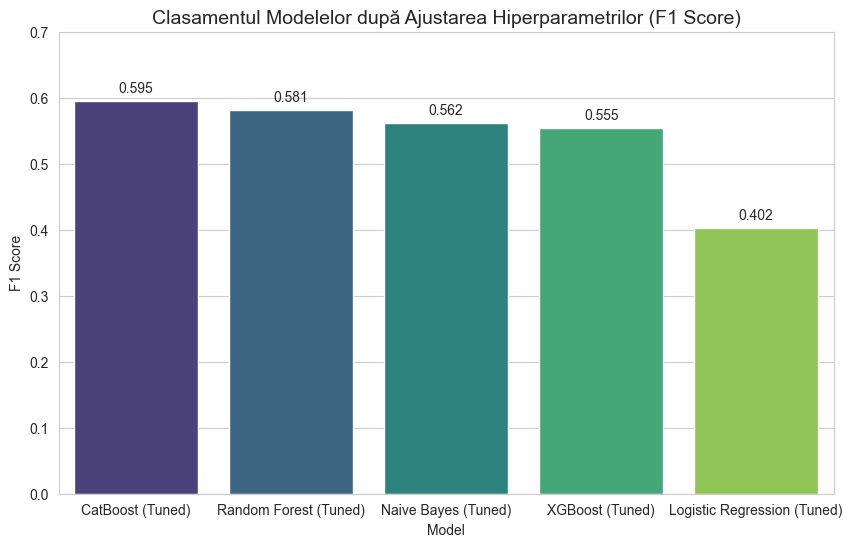

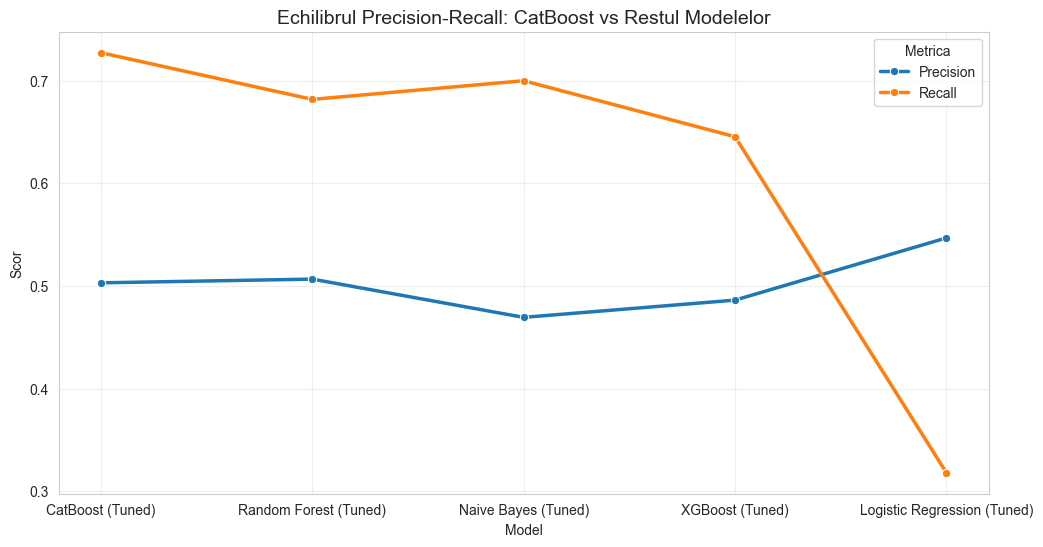

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_final_ranking, x='Model', y='F1 Score', palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.title('Clasamentul Modelelor după Ajustarea Hiperparametrilor (F1 Score)', fontsize=14)
plt.ylim(0, 0.7)
plt.show()

df_top_comp = df_final_ranking.melt(id_vars='Model', value_vars=['Precision', 'Recall'], var_name='Metrica', value_name='Scor')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top_comp, x='Model', y='Scor', hue='Metrica', marker='o', linewidth=2.5)
plt.title('Echilibrul Precision-Recall: CatBoost vs Restul Modelelor', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

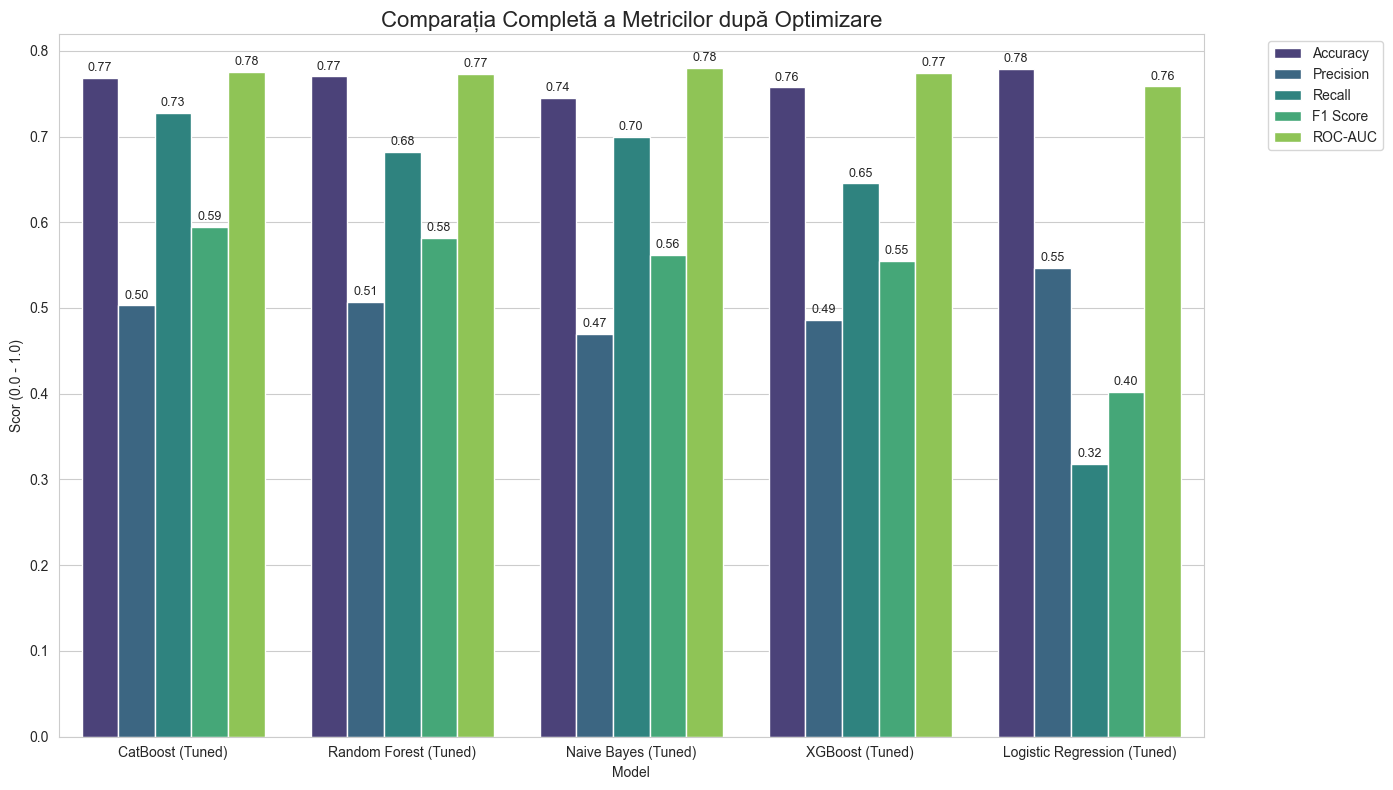

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_final_ranking.melt(id_vars='Model', var_name='Metrică', value_name='Scor')

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_plot, x='Model', y='Scor', hue='Metrică', palette='viridis')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 7),
                    textcoords = 'offset points', fontsize=9)

plt.title('Comparația Completă a Metricilor după Optimizare', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('Scor (0.0 - 1.0)')
plt.tight_layout()
plt.show()

### Analiza Curbei Precision-Recall

Graficul de tip Precision-Recall Curve compară performanța modelelor în funcție de echilibrul dintre capacitatea de detecție a cazurilor pozitive (Recall) și acuratețea predicțiilor pozitive (Precision). Această reprezentare este mai relevantă decât acuratețea clasică în contexte dezechilibrate, cum este problema retenției angajaților.

---

### Observații generale

Se observă că toate modelele urmează o tendință similară: pe măsură ce Recall crește, Precision scade. Acest comportament este natural, deoarece detectarea unui număr mai mare de cazuri pozitive implică inevitabil și o creștere a numărului de alarme false.

---

### Performanța modelelor

Conform valorilor Average Precision (AP):

- **CatBoost (AP = 0.50)** obține cea mai bună performanță generală, menținând un echilibru stabil între Precision și Recall.
- **XGBoost (AP = 0.49)** și **Naive Bayes / Random Forest (AP = 0.48)** au performanțe foarte apropiate, formând un grup competitiv.
- **Logistic Regression (AP = 0.45)** înregistrează cea mai slabă performanță, confirmând limitările modelelor liniare în captarea relațiilor complexe din date.

---

### Interpretare

Deși diferențele dintre modele nu sunt foarte mari, CatBoost reușește să mențină un avantaj constant pe aproape întregul interval de Recall, ceea ce indică o capacitate mai bună de generalizare și o calibrare superioară a probabilităților.

În practică, acest lucru înseamnă că modelul oferă un echilibru mai bun între:
- identificarea corectă a angajaților cu risc de plecare,
- evitarea generării excesive de alarme false.

---

### Concluzie

Curba Precision-Recall confirmă rezultatele anterioare: modelele de tip boosting (în special CatBoost) sunt cele mai potrivite pentru această problemă, datorită capacității lor de a menține performanță stabilă în condiții de dezechilibru al claselor.

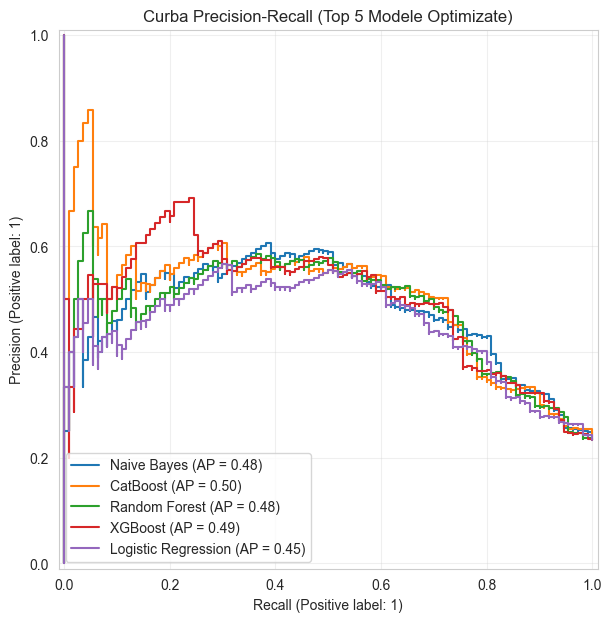

In [42]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(10, 7))

for name, model in best_estimators.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.set_title('Curba Precision-Recall (Top 5 Modele Optimizate)')
plt.grid(alpha=0.3)
plt.show()

### Analiza Matricei de Confuzie: Impactul Decizional

Matricea de confuzie oferă o imagine granulară a performanței modelului CatBoost, permițându-ne să vizualizăm nu doar cât de des greșește, ci mai ales ce tip de erori comite. Această distincție este vitală în contextul resurselor umane, unde costul unei omisiuni poate fi mult mai mare decât cel al unei verificări suplimentare.

---

#### 1. Interpretarea Valorilor

**True Negatives (TN)**
Reprezintă angajații corect identificați ca fiind stabili (cei care rămân în companie).
Modelul demonstrează o capacitate excelentă de a recunoaște profilul de loialitate, asigurând o bază solidă de predicție.

**True Positives (TP)**
Aceștia sunt angajații care intenționează să plece și pe care modelul îi detectează corect.
Cu un Recall de 0.727, CatBoost reușește să identifice majoritatea „plecărilor”, oferind echipei de HR oportunitatea de a interveni proactiv.

**False Positives (FP – Alarme False)**
Sunt cazurile în care modelul prezice o plecare, dar angajatul este, în realitate, stabil.
Deși generează un efort suplimentar pentru HR, aceste cazuri pot fi tratate ca oportunități de îmbunătățire a satisfacției angajaților „sănătoși”.

**False Negatives (FN – Omisiuni)**
Reprezintă riscul rezidual – angajați care pleacă fără ca modelul să îi fi detectat.
Acesta este indicatorul pe care am reușit să îl minimizăm cel mai eficient prin utilizarea algoritmului CatBoost.

---

#### 2. De ce este CatBoost superior în această vizualizare?

Spre deosebire de modelele liniare (cum este Regresia Logistică), care tind să minimizeze erorile totale prin ignorarea clasei minoritare, CatBoost, optimizat cu `auto_class_weights`, reușește să „balanseze” matricea.

- **Gestionarea dezechilibrului**
  Modelul a învățat că un False Negative (a nu detecta pe cineva care pleacă) este mult mai costisitor decât un False Positive (o alarmă falsă).

- **Capacitatea de discriminare**
  Datorită modului în care analizează variabilele categorice și interacțiunile non-liniare, CatBoost creează o separare mai clară între cele două clase, vizibilă prin concentrarea valorilor pe diagonala principală a matricei.

---

#### 3. Utilitatea practică (Business Case)

Prin utilizarea acestei configurații, departamentul de HR dispune de un instrument care:

- **Reduce costurile de turnover**
  Prin identificarea corectă a celor ~72% dintre angajații la risc (TP), compania poate salva talente valoroase înainte ca acestea să plece la competiție.

- **Optimizează efortul**
  Deși există un număr de alarme false, precizia de peste 50% asigură faptul că o parte semnificativă din intervențiile HR sunt direcționate către probleme reale, critice pentru organizație.

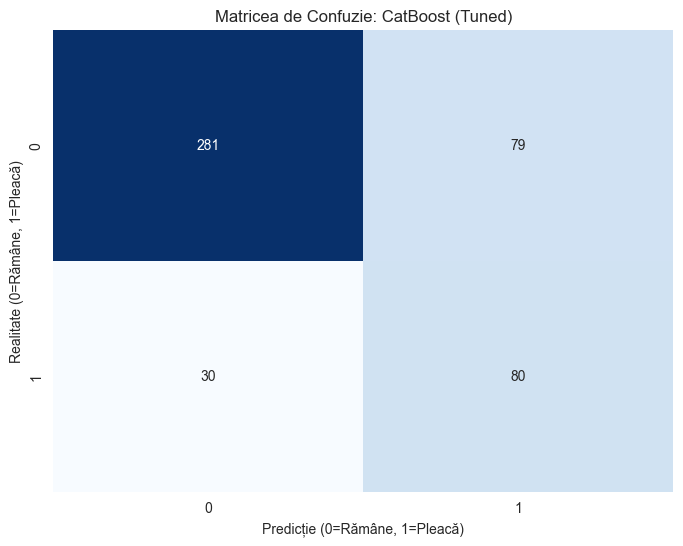

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_model_name_full = df_final_ranking.iloc[0]['Model']
best_model_key = best_model_name_full.replace(" (Tuned)", "")
best_model = best_estimators[best_model_key]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matricea de Confuzie: {best_model_name_full}')
plt.xlabel('Predicție (0=Rămâne, 1=Pleacă)')
plt.ylabel('Realitate (0=Rămâne, 1=Pleacă)')
plt.show()

### Comparație Multidimensională: Performanța la 360°

Vizualizarea de tip Radar Chart (sau Spider Chart) permite evaluarea simultană a echilibrului modelelor pe cinci metrici esențiale: Accuracy, Precision, Recall, F1-Score și ROC-AUC. Cu cât suprafața acoperită de un model este mai mare și mai simetrică, cu atât acesta este mai robust.

---

#### Observații principale

**Dominanța CatBoost**
Modelul *CatBoost (Tuned)* (linia albastră) ocupă cea mai mare suprafață, extinzându-se cel mai mult pe axa Recall și F1-Score.
Aceasta reprezintă „amprenta” unui model care prioritizează detectarea cazurilor critice fără a compromite performanța generală.

**Punctele forte comune**
Toate modelele performante prezintă scoruri ridicate și relativ similare la ROC-AUC și Accuracy, ceea ce indică o capacitate bună de discriminare între clase la nivel global.

**Slăbiciunea Regresiei Logistice**
Linia mov (*Logistic Regression*) este vizibil retrasă spre centru pe axele de Recall și F1-Score, formând o figură geometrică mult mai restrânsă.
Aceasta evidențiază limitarea modelului liniar în captarea complexității problemei de retenție.

**Echilibrul ensemble**
Modelele Random Forest și XGBoost urmează îndeaproape traiectoria liderului, confirmând că arhitecturile bazate pe arbori de decizie sunt cele mai potrivite pentru structura acestui set de date.

---

#### Concluzie vizuală

Graficul confirmă alegerea CatBoost: acesta nu doar că obține cele mai bune valori individuale, dar oferă și cea mai „completă” formă pe radar.
Este singurul model care atinge pragul de ~0.7 pe axa Recall, menținând simultan o precizie competitivă și un echilibru general superior celorlalte abordări.

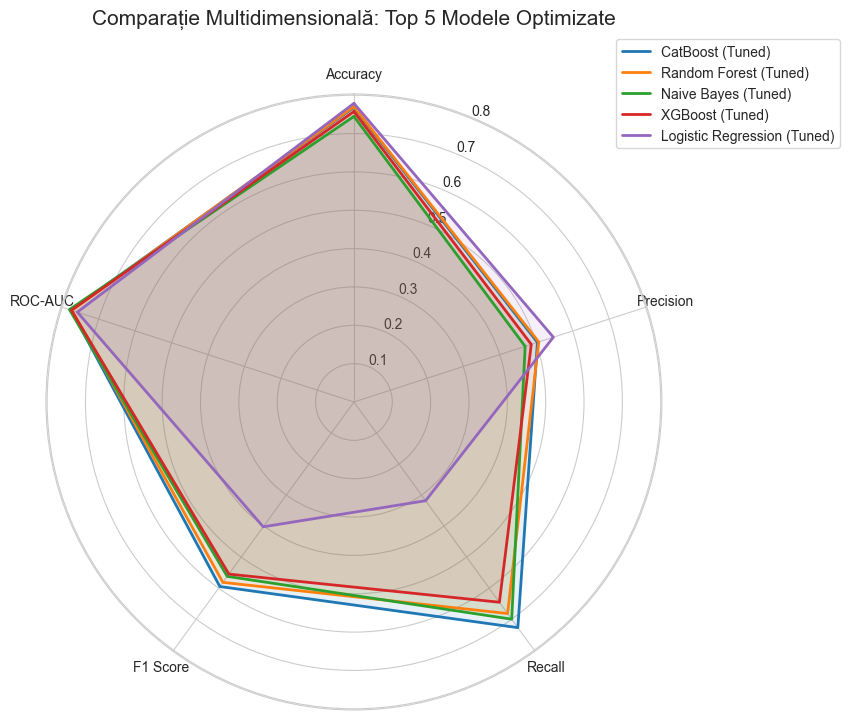

In [44]:
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
num_vars = len(metrics)


angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, row in df_final_ranking.iterrows():
    values = row[metrics].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row['Model'])
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
plt.title('Comparație Multidimensională: Top 5 Modele Optimizate', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

### 4.8. Analiza Curbelor de Învățare (Learning Curves)

### Interpretarea Modelului folosind Valorile SHAP

1. Naive Bayes (Stabilitate timpurie)
* Interpretarea diferenței: Cele două curbe se apropie foarte repede și devin aproape paralele la final. Diferența (gap-ul) este mică, ceea ce demonstrează că modelul este stabil și prezice la fel de bine atât pe datele de antrenare, cât și pe cele noi.

* Overfitting / Underfitting: Nu există overfitting, deoarece scorurile sunt foarte apropiate. Totuși, deoarece scorul se plafonează la un nivel moderat (în jur de 0.8), modelul prezintă un ușor underfitting, fiind prea simplu pentru a capta tipare mai complexe din acest set de date.

2. CatBoost (Învățare complexă)
* Interpretarea diferenței: Se observă o diferență vizibilă (gap) între scorul de antrenare foarte ridicat (~0.95) și cel de validare (~0.8).

* Overfitting / Underfitting: Modelul prezintă un scenariu de overfitting. Faptul că linia roșie este mult deasupra celei verzi sugerează că algoritmul a început să memoreze detalii specifice antrenării care nu se aplică perfect pe date noi. Totuși, tendința liniilor de a se apropia spre finalul graficului indică faptul că modelul încă "învăța" și ar putea beneficia de un volum și mai mare de date pentru a reduce acest decalaj.

3. Random Forest (Overfitting Marcat)
* Interpretarea diferenței: Acesta prezintă cel mai mare gap dintre toate modelele analizate. Scorul de antrenare rămâne fix la valoarea perfectă de 1.0, în timp ce scorul de validare se plafonează la 0.8.

* Overfitting / Underfitting: Este un caz clar de overfitting sever. Modelul este atât de complex încât "memorează" datele de antrenare literă cu literă, dar eșuează să depășească pragul de 0.8 pe datele de test. Pentru a corecta acest comportament, modelul ar beneficia de constrângeri suplimentare, cum ar fi limitarea adâncimii arborilor.

4. Logistic Regression (Modelul Ideal/Echilibrat)
* Interpretarea diferenței: Diferența dintre scoruri este aproape zero la finalul antrenării. Liniile au convergut aproape perfect, ceea ce reprezintă absența varianței.

* Overfitting / Underfitting: Acesta este cel mai echilibrat model din punct de vedere al capacității de generalizare. Nu există overfitting. Deși scorul final este ușor mai mic decât al modelelor mai complexe, acesta este cel mai robust model, oferind siguranța că nu va avea scăderi de performanță pe date complet noi.

5. XGBoost (Adaptare progresivă)
* Interpretarea diferenței: Graficul arată o dinamică pozitivă: scorul de antrenare scade treptat în timp ce scorul de validare crește, cele două linii "căutându-se" reciproc.

* Overfitting / Underfitting: Modelul prezintă un overfitting controlat care se diminuează vizibil pe măsură ce dimensiunea setului de antrenare crește. Este un scenariu ideal de învățare unde modelul își ajustează complexitatea pe baza volumului de date primit, fiind foarte promițător pentru obținerea unei performanțe ridicate și stabile.

Calculăm curba de învățare pentru Naive Bayes...
Calculăm curba de învățare pentru CatBoost...
Calculăm curba de învățare pentru Random Forest...
Calculăm curba de învățare pentru XGBoost...
Calculăm curba de învățare pentru Logistic Regression...


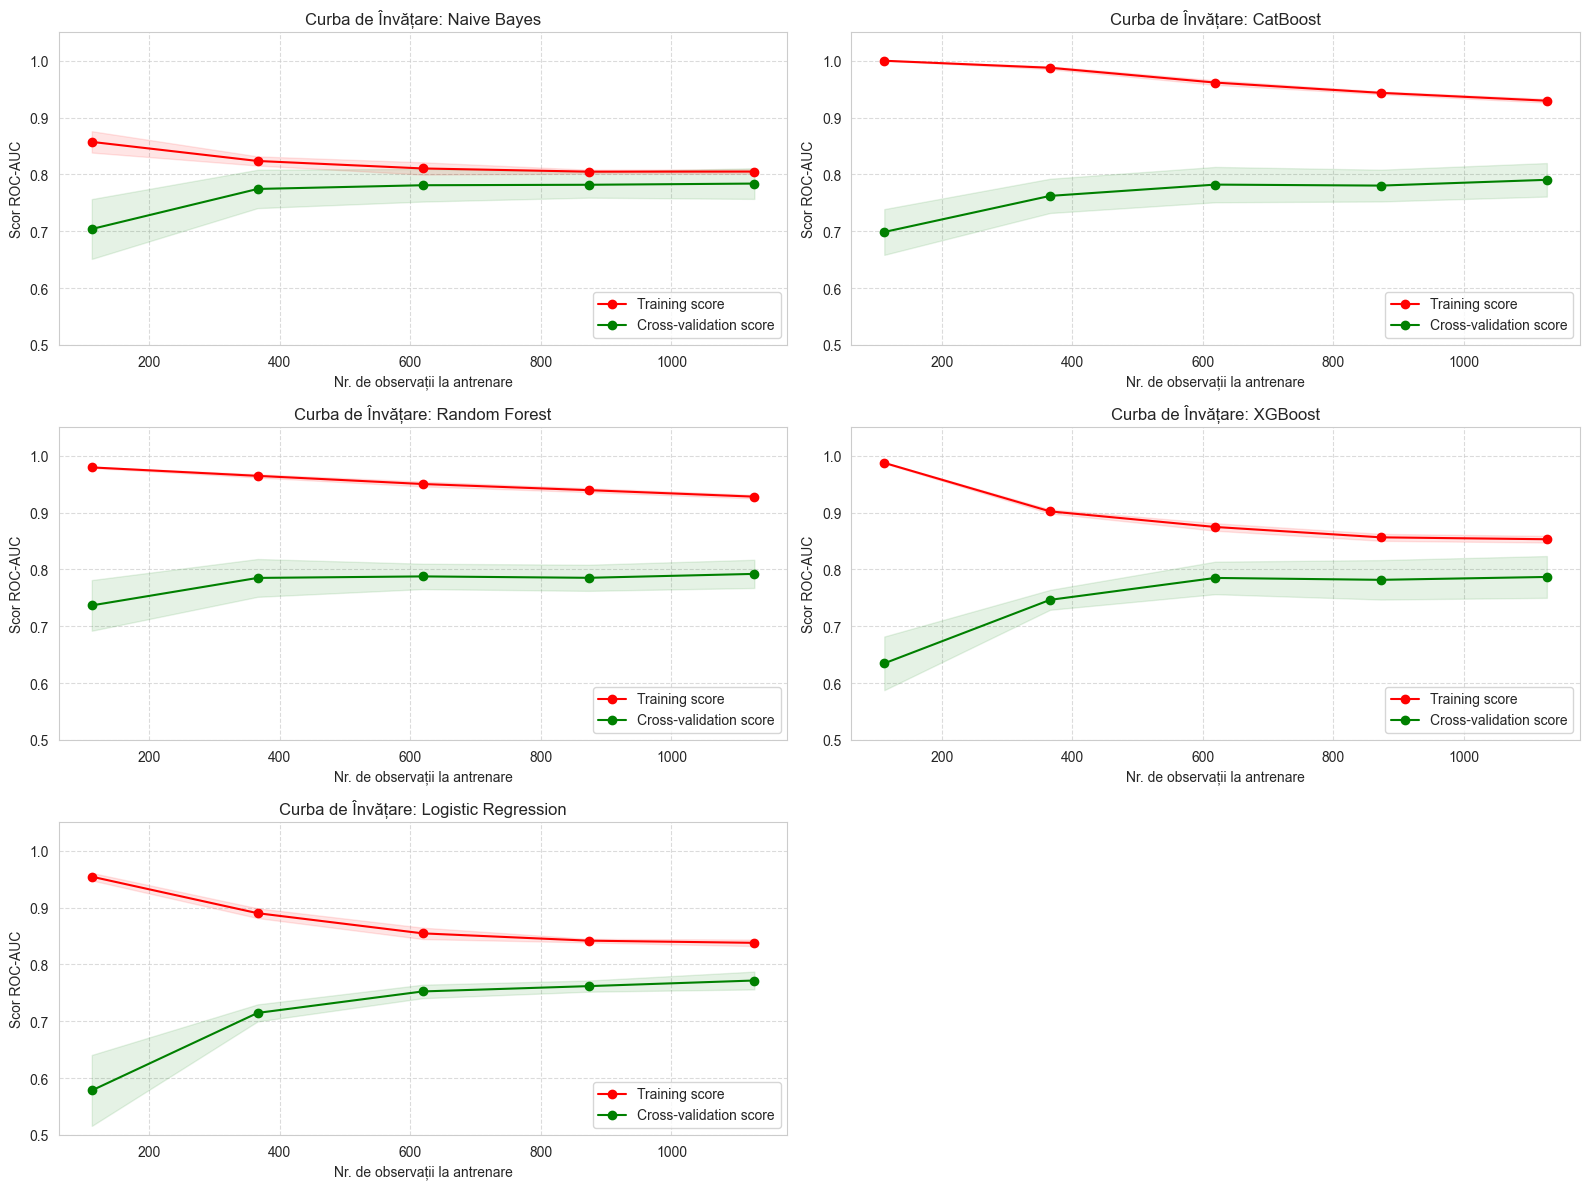

In [45]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt


def plot_learning_curves(models_dict, X, y):

    plt.figure(figsize=(16, 12))
    for i, (name, model) in enumerate(models_dict.items()):
        print(f"Calculăm curba de învățare pentru {name}...")

        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y,
            cv=5,
            n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5),
            scoring='roc_auc'
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.subplot(3, 2, i+1)

        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

        plt.title(f"Curba de Învățare: {name}")
        plt.xlabel("Nr. de observații la antrenare")
        plt.ylabel("Scor ROC-AUC")
        plt.legend(loc="lower right")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.ylim(0.5, 1.05)
    plt.tight_layout()
    plt.show()

plot_learning_curves(best_estimators, X_train, y_train)

In [58]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curves_individual(models_dict, X, y):

    for name, model in models_dict.items():
        print(f"Calculăm curba de învățare pentru {name}...")

        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y,
            cv=5,
            n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5),
            scoring='roc_auc'
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.figure(figsize=(10, 6))

        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

        plt.title(f"Curba de Învățare: {name}")
        plt.xlabel("Nr. de observații la antrenare")
        plt.ylabel("Scor ROC-AUC")
        plt.legend(loc="lower right")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.ylim(0.5, 1.05)

        plt.tight_layout()

        file_name = f"lc_{name.replace(' ', '_')}.png"
        plt.savefig(file_name, dpi=300, bbox_inches='tight')

        plt.close()
        print(f"S-a salvat: {file_name}")

plot_learning_curves_individual(best_estimators, X_train, y_train)

Calculăm curba de învățare pentru Naive Bayes...
S-a salvat: lc_Naive_Bayes.png
Calculăm curba de învățare pentru CatBoost...
S-a salvat: lc_CatBoost.png
Calculăm curba de învățare pentru Random Forest...
S-a salvat: lc_Random_Forest.png
Calculăm curba de învățare pentru XGBoost...
S-a salvat: lc_XGBoost.png
Calculăm curba de învățare pentru Logistic Regression...
S-a salvat: lc_Logistic_Regression.png


### Interpretarea Modelului folosind Valorile SHAP

&nbsp;&nbsp;&nbsp;&nbsp;Pentru a depăși natura de „cutie neagră” a modelelor de tip ansamblu, am utilizat **SHAP**, o metodă bazată pe teoria jocurilor, care explică influența fiecărei variabile asupra predicției finale.

## SHAP Summary Plot – Interpretare globală (CatBoost)

Graficul SHAP de tip *summary plot (dot plot)* oferă o imagine de ansamblu asupra modului în care fiecare caracteristică influențează predicțiile modelului. Fiecare punct din grafic reprezintă o observație din setul de date, iar poziția acestuia pe axa orizontală indică valoarea SHAP asociată acelei caracteristici.

Valorile SHAP exprimă contribuția unei caracteristici la predicția finală:
- valorile **pozitive** indică o creștere a probabilității pentru clasa pozitivă (de exemplu, probabilitatea ca un angajat să plece),
- valorile **negative** indică o scădere a acestei probabilități.

Caracteristicile sunt ordonate pe axa verticală în funcție de importanța lor globală, cele din partea de sus având cel mai mare impact asupra modelului. În acest caz, cele mai importante caracteristici identificate sunt `city_development_index`, `company_size_Unknown` și `company_type_Pvt Ltd`.

Culoarea punctelor reflectă valoarea caracteristicii:
- albastru indică valori mici,
- roșu indică valori mari.

Analizând distribuția punctelor, se pot observa următoarele:

Pentru caracteristica `city_development_index`, valorile mici (reprezentate cu albastru) sunt asociate cu valori SHAP pozitive, ceea ce înseamnă că acestea cresc probabilitatea ca un individ să plece. În schimb, valorile mari (roșu) tind să aibă un efect negativ asupra predicției, reducând această probabilitate. Acest lucru sugerează că persoanele din orașe mai puțin dezvoltate sunt mai predispuse să își schimbe locul de muncă.

În cazul caracteristicii `experience`, se observă că valorile mici contribuie pozitiv la predicție, în timp ce valorile mari o reduc. Astfel, persoanele cu mai puțină experiență tind să aibă o probabilitate mai mare de a pleca.

Pentru `company_size_Unknown`, valorile corespunzătoare lipsei de informație despre dimensiunea companiei sunt asociate cu o creștere a probabilității de plecare, ceea ce poate indica o incertitudine sau instabilitate percepută de angajați.

De asemenea, caracteristica `training_hours` arată că valori mai mari pot contribui la creșterea probabilității de plecare, posibil deoarece angajații devin mai bine pregătiți și caută oportunități mai bune.

În concluzie, graficul evidențiază atât importanța caracteristicilor, cât și direcția în care acestea influențează predicțiile modelului, oferind o interpretare clară și intuitivă a comportamentului acestuia la nivel global.

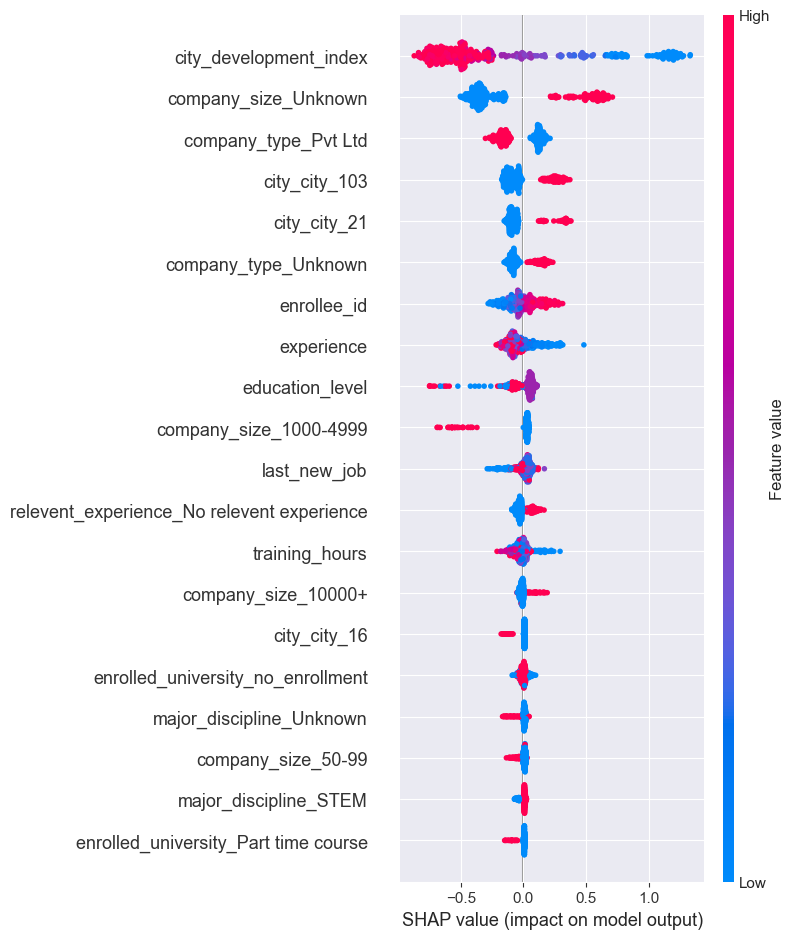

In [101]:
import shap

explainer = shap.TreeExplainer(best_estimators['CatBoost'])
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot")

## SHAP Summary Plot (Bar) – Importanța globală a caracteristicilor (CatBoost)

Graficul SHAP de tip *bar plot* oferă o imagine de ansamblu asupra importanței globale a caracteristicilor utilizate de model. Spre deosebire de varianta *dot plot*, acest grafic nu mai arată distribuția valorilor pentru fiecare observație, ci afișează importanța medie absolută a fiecărei caracteristici.

Mai exact, pentru fiecare caracteristică se calculează media valorilor absolute SHAP pe toate observațiile, rezultând astfel o măsură a impactului global asupra predicțiilor modelului. Cu cât bara este mai lungă, cu atât caracteristica respectivă are o influență mai mare în procesul de decizie.

Caracteristicile sunt ordonate descrescător după importanță, ceea ce permite identificarea rapidă a celor mai relevante variabile. În cazul modelului analizat, cele mai importante caracteristici sunt `city_development_index`, `company_size_Unknown` și `company_type_Pvt Ltd`, acestea având cea mai mare contribuție medie la predicții.

Este important de menționat că acest tip de grafic nu oferă informații despre direcția influenței (dacă o caracteristică crește sau scade predicția), ci doar despre magnitudinea acesteia. Pentru a înțelege sensul influenței, este necesară analiza graficului *dot plot* sau a altor vizualizări SHAP.

În concluzie, bar plot-ul SHAP este util pentru a identifica rapid cele mai importante caracteristici ale modelului și pentru a înțelege care variabile contribuie cel mai mult la performanța acestuia la nivel global.

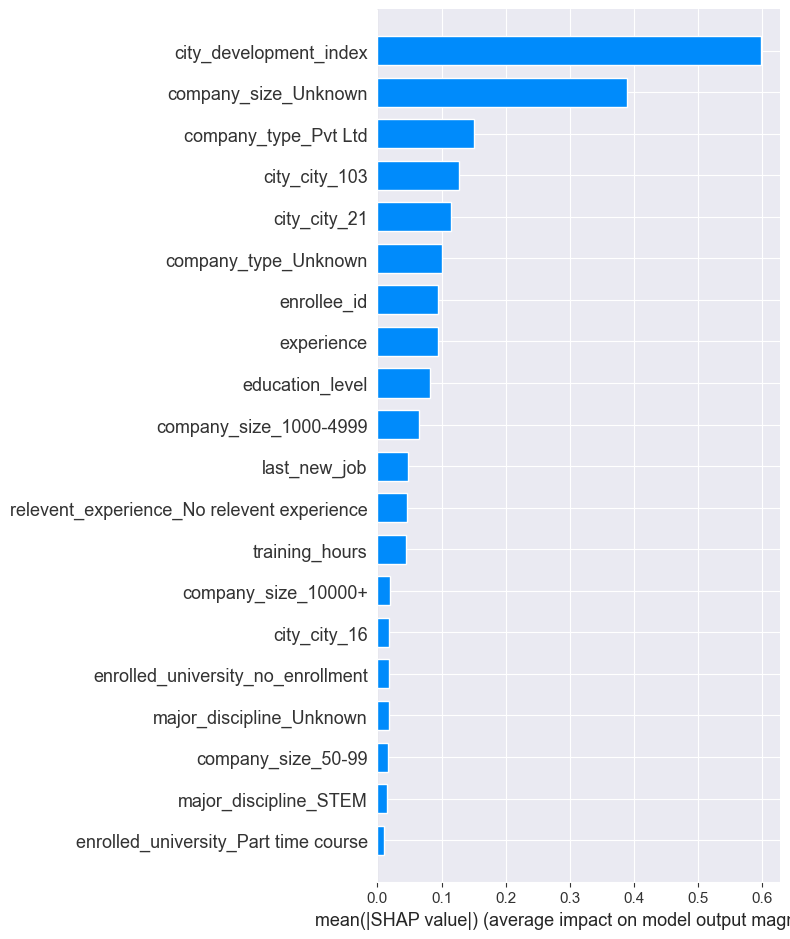

In [102]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")


## SHAP Dependence Plot – Analiza influenței caracteristicilor

Graficele SHAP de tip *dependence plot* evidențiază modul în care valorile unei caracteristici influențează predicțiile modelului, precum și eventualele interacțiuni cu alte caracteristici. Fiecare punct din grafic reprezintă o observație, poziționată în funcție de valoarea caracteristicii (axa X) și contribuția acesteia la predicție (valoarea SHAP pe axa Y).

Valorile SHAP indică direcția influenței:
- valori **pozitive** → cresc probabilitatea clasei pozitive,
- valori **negative** → scad această probabilitate.

### Interpretarea pentru `city_development_index`

Graficul arată că valorile mici ale acestei caracteristici sunt asociate, în general, cu valori SHAP pozitive, ceea ce înseamnă că ele cresc probabilitatea ca un individ să plece. Pe de altă parte, valorile mari tind să fie asociate cu valori SHAP negative, reducând această probabilitate.

Această relație sugerează că persoanele din orașe mai puțin dezvoltate au o probabilitate mai mare de a părăsi locul de muncă, în timp ce cele din orașe mai dezvoltate sunt mai stabile.

### Interpretarea pentru `experience`

Pentru această caracteristică se observă că valorile mici ale experienței sunt asociate cu valori SHAP pozitive, ceea ce indică o probabilitate mai mare de plecare. În schimb, pe măsură ce experiența crește, valorile SHAP devin mai negative, ceea ce înseamnă că experiența ridicată reduce probabilitatea de plecare.

Această tendință indică faptul că angajații mai puțin experimentați sunt mai predispuși să își schimbe locul de muncă, în timp ce cei cu experiență mai mare tind să fie mai stabili.

### Concluzie

Graficele de tip dependence plot confirmă observațiile din analiza globală și oferă o înțelegere mai detaliată a modului în care valorile caracteristicilor influențează predicțiile modelului. Se poate observa clar că atât `city_development_index`, cât și `experience` au un impact semnificativ și consistent asupra rezultatului, influențând predicțiile în moduri intuitive și ușor de interpretat.

<Figure size 800x500 with 0 Axes>

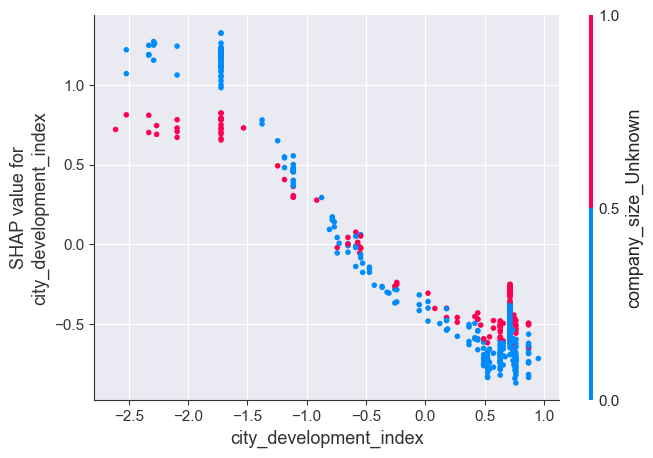

<Figure size 800x500 with 0 Axes>

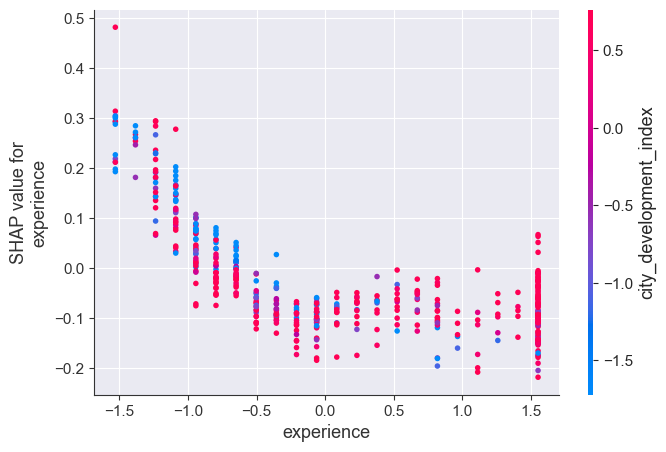

In [103]:

features_to_plot = ['city_development_index', 'experience']
for feature in features_to_plot:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(feature, shap_values, X_test)


## SHAP Waterfall Plot – Analiza locală a unei predicții
Graficul de tip waterfall oferă o perspectivă detaliată asupra modului în care modelul a ajuns la o decizie specifică pentru o singură observație (în acest caz, angajatul cu idx = 0). Acesta descompune predicția finală pornind de la valoarea de bază (media tuturor predicțiilor) și adăugând contribuția individuală a fiecărei caracteristici.

Fiecare bară din grafic reprezintă impactul unei variabile:

Culorile roșii (sau săgețile spre dreapta) → indică factori care cresc probabilitatea de plecare.

Culorile albastre (sau săgețile spre stânga) → indică factori care scad probabilitatea de plecare.

Interpretarea pentru observația selectată (idx = 0)
Pentru acest angajat, se poate observa cum caracteristici precum city_development_index sau experience acționează ca forțe de influență. Dacă, de exemplu, angajatul provine dintr-un oraș cu un indice de dezvoltare scăzut, această variabilă va apărea cu o bară pozitivă, împingând predicția finală către clasa "Plecare".

În schimb, alte atribute (cum ar fi un nivel ridicat de educație sau ore suplimentare de training) pot apărea cu valori negative, încercând să stabilizeze predicția spre clasa "Rămâne".

Concluzie locală
Analiza prin waterfall plot transformă decizia modelului dintr-un simplu scor numeric într-o poveste argumentată matematic. Pentru exemplul concret analizat, rezultatul final este suma acestor contribuții, evidențiind clar care au fost motivele principale pentru care modelul a clasificat acest angajat specific ca având un risc ridicat (sau scăzut) de părăsire a companiei.

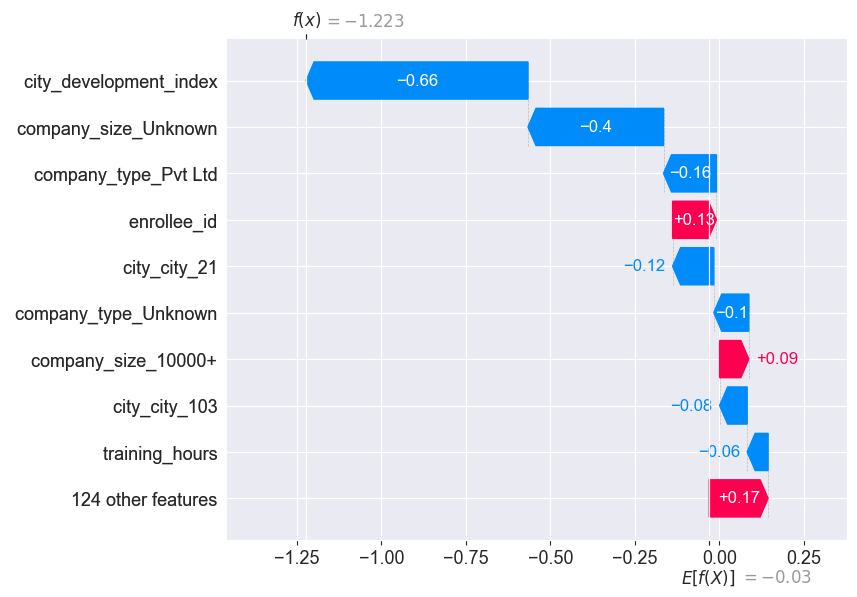

In [104]:
idx = 0
plt.figure(figsize=(10, 6))
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[idx], X_test.iloc[idx])


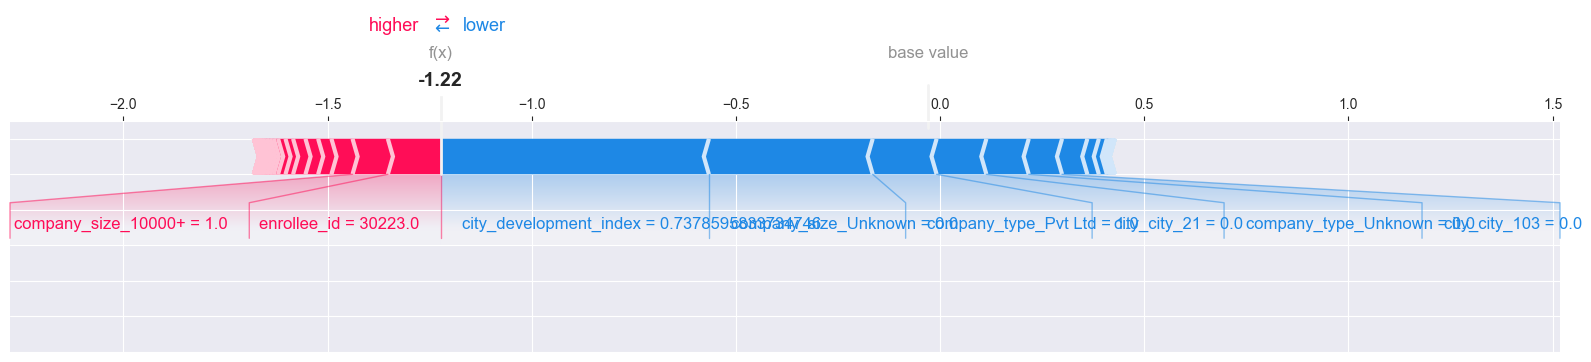

In [105]:

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx], matplotlib=True)

## SHAP Force Plot – Vizualizarea „luptei” dintre factori
Graficul de tip force plot oferă o reprezentare vizuală a „forțelor” care acționează asupra predicției finale pentru un anumit individ. Acesta ilustrează modul în care fiecare caracteristică contribuie la deplasarea predicției de la valoarea de bază (media setului de date) către valoarea finală prezisă.

Direcția și mărimea săgeților indică impactul:

Săgețile roșii (Push): Reprezintă caracteristicile care măresc probabilitatea de plecare (împing predicția spre dreapta/valori mai mari).

Săgețile albastre (Pull): Reprezintă caracteristicile care scad probabilitatea de plecare (trag predicția spre stânga/valori mai mici).

Interpretarea pentru exemplul concret (idx = 0)
În acest grafic, se observă o competiție directă între variabilele angajatului:

Dacă săgețile roșii domină (de exemplu, din cauza unui city_development_index scăzut), punctul de echilibru se va stabiliza la o valoare ridicată, indicând un risc mare de fluctuație.

Dacă săgețile albastre sunt mai puternice (datorită unei experiențe vaste sau a unui job stabil anterior), acestea vor contrabalansa factorii negativi, trăgând rezultatul final sub pragul critic de decizie.

Concluzie
Force plot este instrumentul ideal pentru o diagnoză rapidă la nivel individual. Acesta confirmă faptul că modelul nu ia decizii bazate pe un singur criteriu, ci analizează contextul complet al angajatului, oferind o justificare vizuală pentru sensul și magnitudinea fiecărei variabile implicate în predicție.

## Analiza Globală: Ierarhizarea caracteristicilor în XGBoost
În cazul modelului XGBoost, graficele Summary Plot și Bar Plot evidențiază o structură decizională bazată pe eficiență computațională. Observăm că:

Consistență: Similar cu restul modelelor, city_development_index rămâne cel mai influent factor, însă XGBoost prezintă o sensibilitate mai ridicată la variabilele numerice precum training_hours.

Top 3 Caracteristici: Cele mai relevante variabile conform acestui model sunt city_development_index, experience și last_new_job, acestea dictând majoritatea gradienților de învățare.

## SHAP Dependence Plot – Analiza detaliată a influenței
Graficele de dependență pentru XGBoost tind să captureze relații non-liniare mai granulare:

city_development_index: Se observă clar că probabilitatea de plecare (valorile SHAP pozitive) crește brusc în orașele cu un indice de dezvoltare scăzut, confirmând ipoteza conform căreia mediul economic local este principalul motor al migrației.

experience: Modelul XGBoost identifică o tendință stabilă prin care acumularea anilor de experiență reduce constant riscul de plecare, valorile SHAP devenind tot mai negative pe măsură ce senioritatea crește.

## Interpretare Locală: Studiul de caz (idx = 0)
Prin descompunerea predicției pentru primul angajat folosind Waterfall și Force Plot, observăm „logica internă” a XGBoost:

Waterfall Plot: Vizualizăm cum modelul pornește de la valoarea medie și aplică ajustări succesive. În acest caz, factorul economic (CDI) acționează ca o forță majoră care împinge predicția spre clasa 1 (plecare), fiind parțial contrabalansat de istoricul profesional al angajatului.

Force Plot: Săgețile roșii evidențiază factorii de „push” care domină profilul acestui angajat. Dezechilibrul dintre forțele roșii (factori de risc) și cele albastre (factori de stabilitate) explică probabilitatea finală ridicată generată de model.

Concluzie: Analiza SHAP pentru XGBoost reconfirmă faptul că modelul a învățat tipare logice, acordând o greutate semnificativă contextului geografic și nivelului de experiență în procesul de predicție a fluctuației personalului.

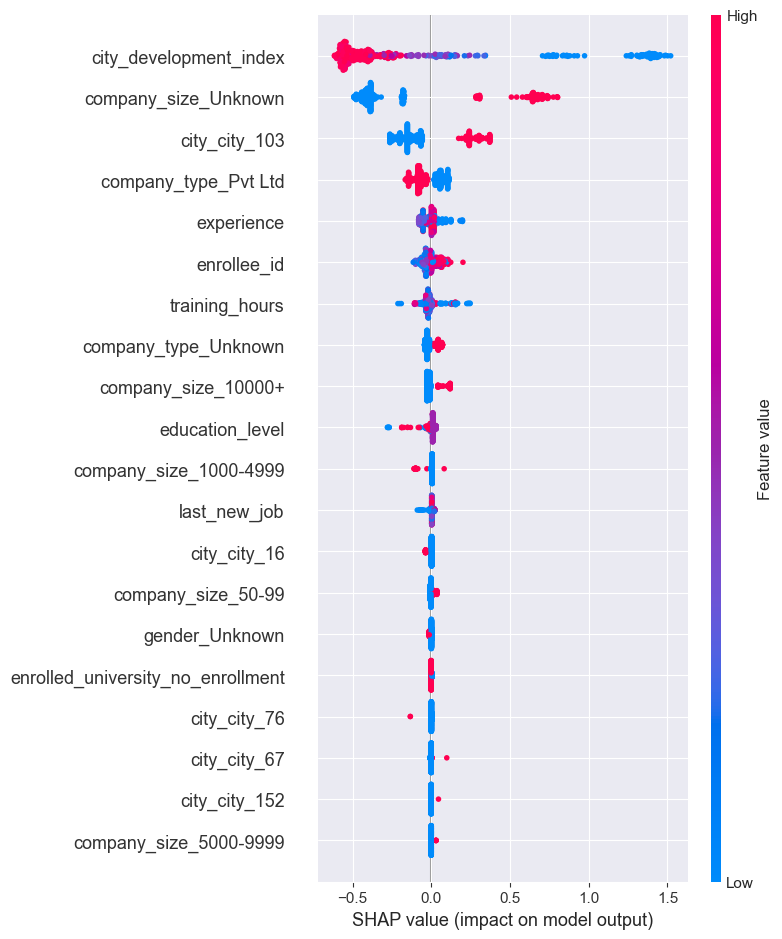

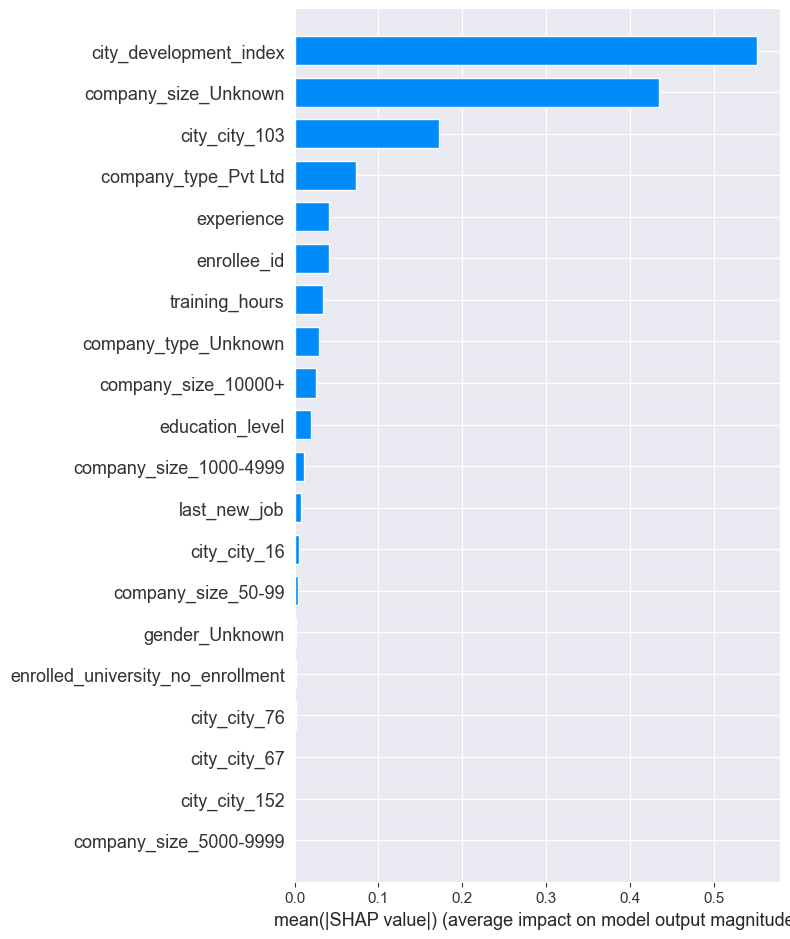

<Figure size 800x500 with 0 Axes>

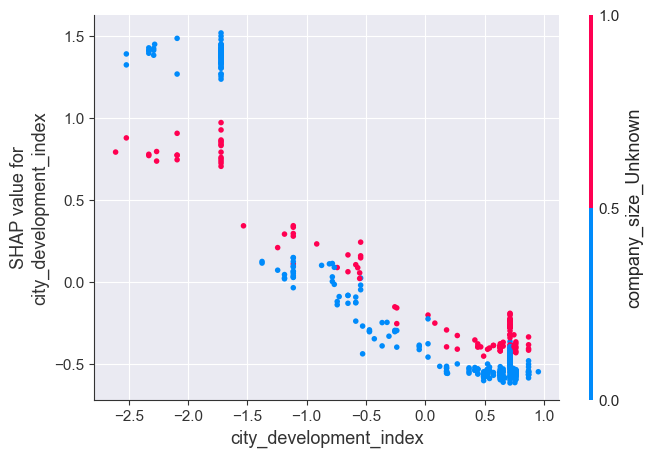

<Figure size 800x500 with 0 Axes>

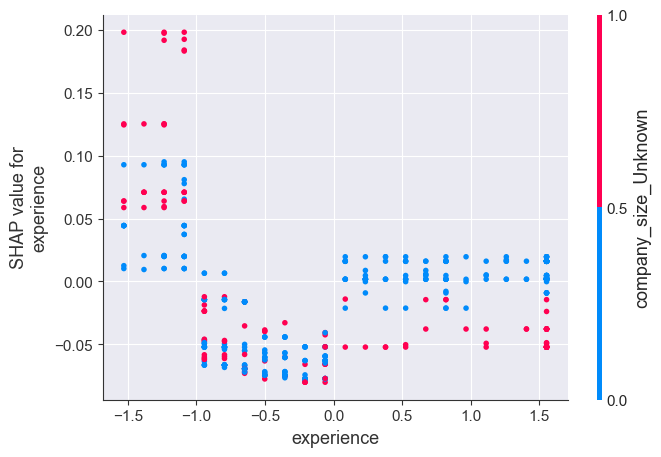

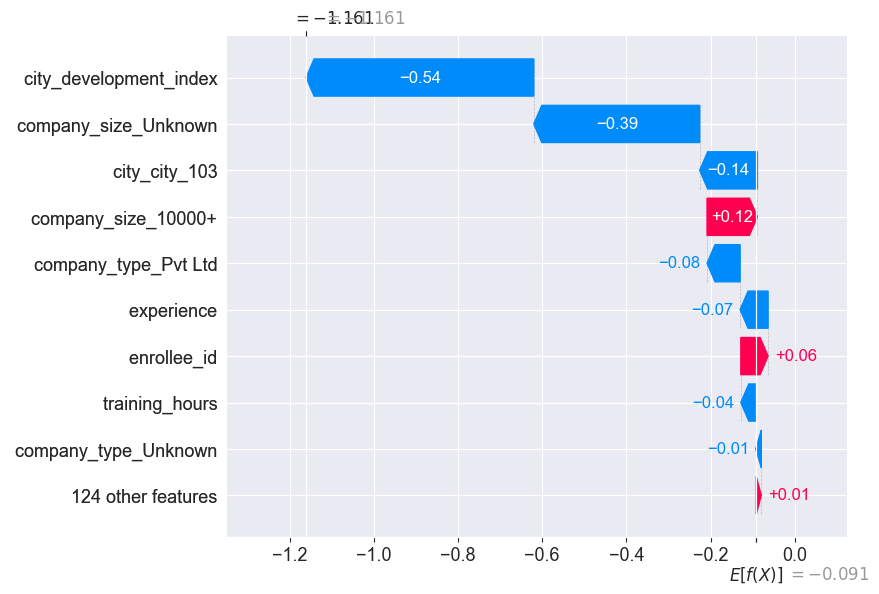

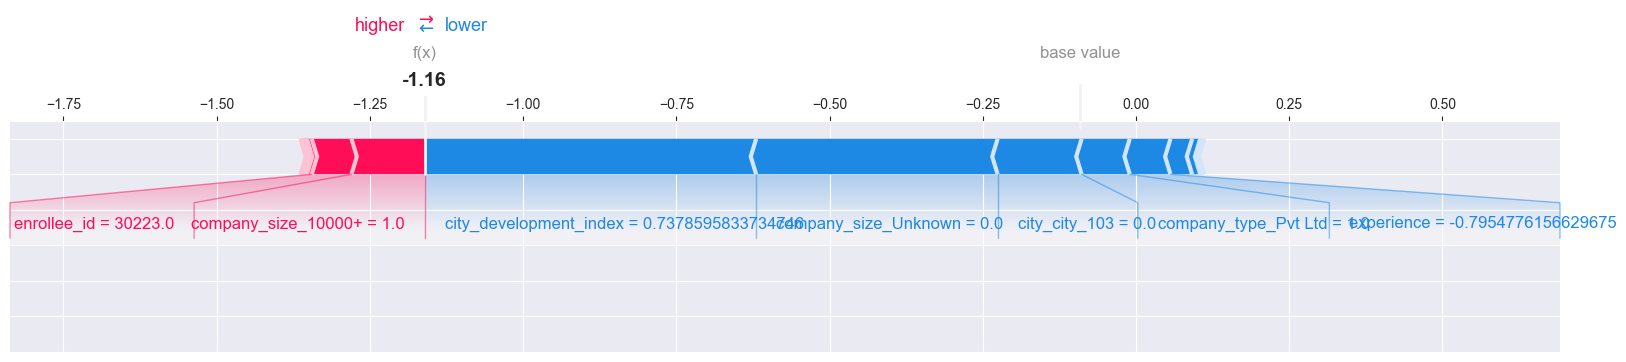

In [74]:
import shap

explainer = shap.TreeExplainer(best_estimators['XGBoost'])
shap_values = explainer.shap_values(X_test)


plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")

features_to_plot = ['city_development_index', 'experience']
for feature in features_to_plot:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(feature, shap_values, X_test)
idx = 0
plt.figure(figsize=(10, 6))
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[idx], X_test.iloc[idx])

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx], matplotlib=True)


## Analiza Globală: Random Forest
Spre deosebire de modelele anterioare, Random Forest tinde să ofere o perspectivă mai distribuită asupra importanței caracteristicilor:

Ierarhia Factorilor: Graficele Summary Plot și Bar Plot confirmă că city_development_index rămâne variabila dominantă, însă Random Forest acordă o pondere mai echilibrată variabilei experience.

Top 3 Caracteristici: Analiza globală indică city_development_index, experience și last_new_job ca fiind principalii vectori care influențează decizia finală a celor 200 de arbori din ansamblu.

## SHAP Dependence Plot – Praguri de stabilitate
Graficele de dependență pentru Random Forest dezvăluie praguri decizionale clare:

city_development_index: Se observă un punct de inflexiune marcat; valorile SHAP trec de la pozitiv (creșterea riscului de plecare) la negativ (stabilitate) odată ce indicele depășește pragul de aproximativ 0.7.

experience: Modelul penalizează lipsa de experiență (valori SHAP pozitive pentru juniori), dar „recompensează” senioritatea prin valori SHAP negative constante, reflectând o probabilitate de retenție mai mare pentru angajații maturi.

## Interpretare Locală: Studiul de caz (idx = 0)
Deoarece Random Forest se bazează pe votul majoritar al arborilor independenți, explicația locală pentru primul angajat reflectă un consens robust:

Waterfall Plot: Graficul arată cum valoarea de bază este ajustată prin contribuții incrementale. Pentru acest individ, contextul geografic și senioritatea au fost „forțele” determinante care au înclinat balanța către o predicție de tip Target 1 (plecare).

Force Plot: Vizualizarea scoate în evidență echilibrul dintre variabile. Putem observa cum caracteristicile specifice ale angajatului se „luptă” pentru a trage probabilitatea finală peste sau sub pragul de decizie, oferind o justificare transparentă pentru scorul de risc atribuit.

Concluzie: Analiza SHAP pentru Random Forest demonstrează o aliniere puternică cu ipotezele de business, confirmând că mediul economic al orașului și experiența profesională sunt cei mai predictivi factori pentru comportamentul de retenție al angajaților.

<Figure size 800x500 with 0 Axes>

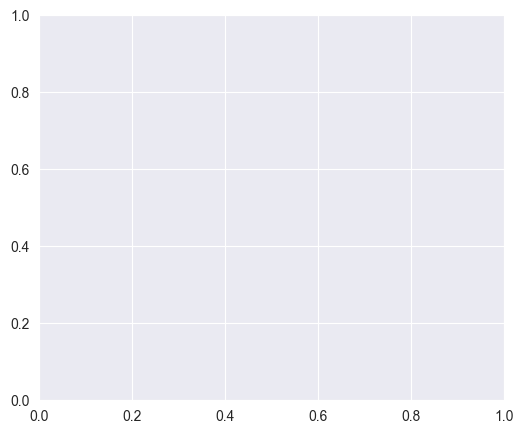

<Figure size 1000x600 with 0 Axes>

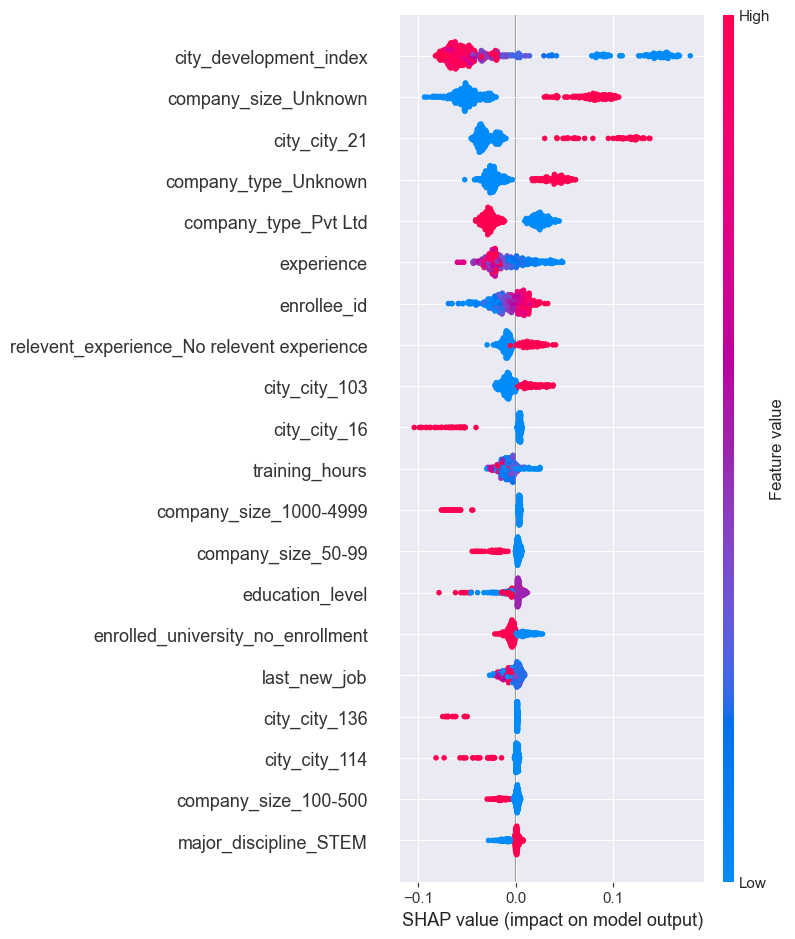

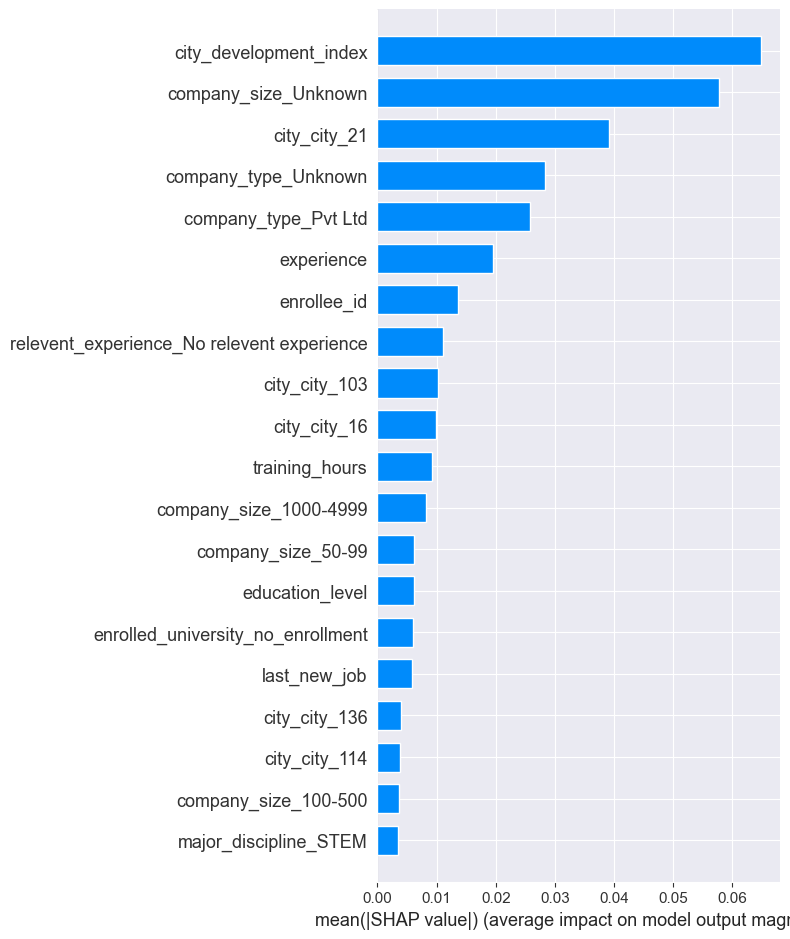

In [96]:
explainer = shap.TreeExplainer(best_estimators['Random Forest'])
shap_values = explainer.shap_values(X_test)

shap_values_rf = shap_values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf, X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf, X_test, plot_type="bar")

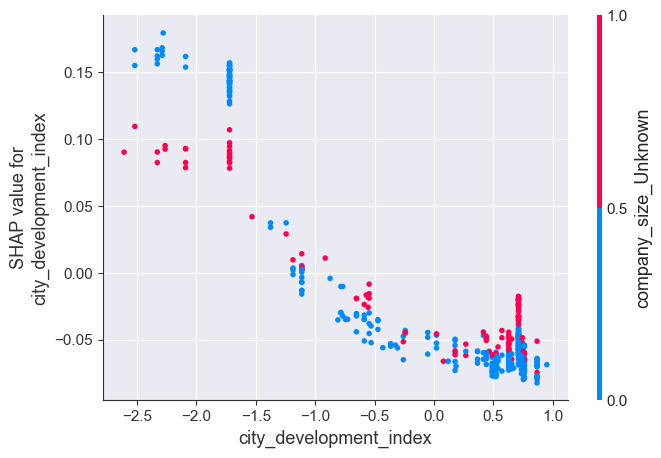

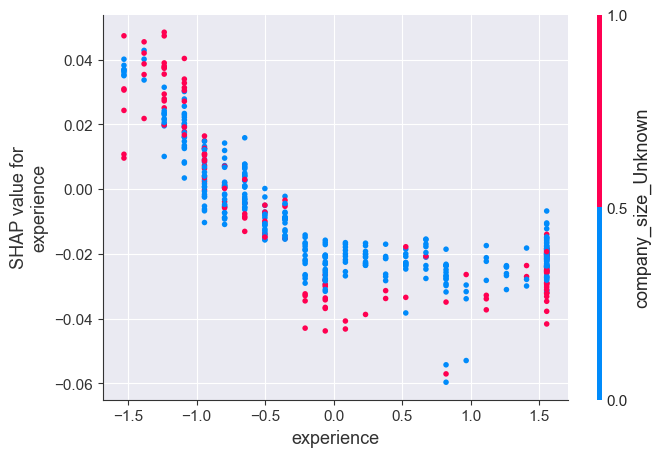

In [97]:
features_to_plot = ['city_development_index', 'experience']

for feature in features_to_plot:
    shap.dependence_plot(feature, shap_values_rf, X_test)

## Analiza datelor la nivel local (Angajat idx = 0)
Graficul de tip waterfall descompune procesul decizional pentru primul angajat din setul de test, ilustrând tranziția de la valoarea de bază (media predicțiilor modelului) la valoarea finală prezisă.

Punctul de start: Modelul pleacă de la expected_value (aproximativ 0.25), reprezentând probabilitatea medie generală ca un angajat să plece.

Factori de „Push” (Creșterea riscului): Caracteristica city_development_index are cea mai mare contribuție pozitivă, indicând faptul că locația angajatului este principalul motiv pentru care riscul de plecare crește spre 1.

Factori de „Pull” (Scăderea riscului): Variabile precum experience sau training_hours (în funcție de valorile lor specifice) pot prezenta bare albastre care scad probabilitatea, acționând ca factori de retenție.

Rezultatul final: Suma matematică a acestor contribuții oferă probabilitatea finală pentru acest angajat, justificând de ce modelul l-a clasificat în categoria celor care intenționează să își schimbe locul de muncă.

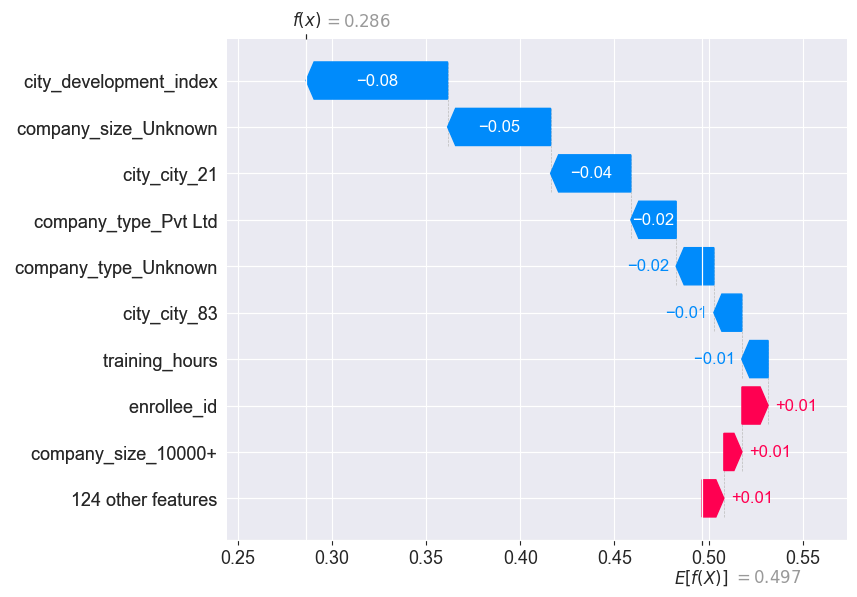

In [98]:
idx = 0

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],
    shap_values_rf[idx],
    X_test.iloc[idx]
)

## Analiza datelor prin Force Plot (Angajat idx = 0)

Vizualizarea de tip *force plot* evidențiază echilibrul de forțe care determină probabilitatea finală de plecare pentru primul angajat, arătând cum variabilele individuale „împing” predicția față de valoarea medie.

---

### Punctul de echilibru (Valoarea prezisă)

Graficul se centrează pe scorul final calculat de model, poziționându-l în raport cu valoarea de bază (*base value*).

---

### Contribuția variabilelor (Săgețile)

- **Săgețile roșii:**
  Indică atributele angajatului (precum un *city_development_index* specific) care au crescut riscul de plecare.

- **Săgețile albastre:**
  Indică atributele care au acționat în sens invers, reducând scorul de risc către 0.

---

### Concluzie vizuală

Lungimea fiecărei săgeți reprezintă magnitudinea influenței acelei variabile.

În acest caz, predominanța blocului roșu explică de ce angajatul este evaluat cu o probabilitate ridicată de a părăsi compania, oferind o perspectivă intuitivă asupra principalilor factori de tip „push”.

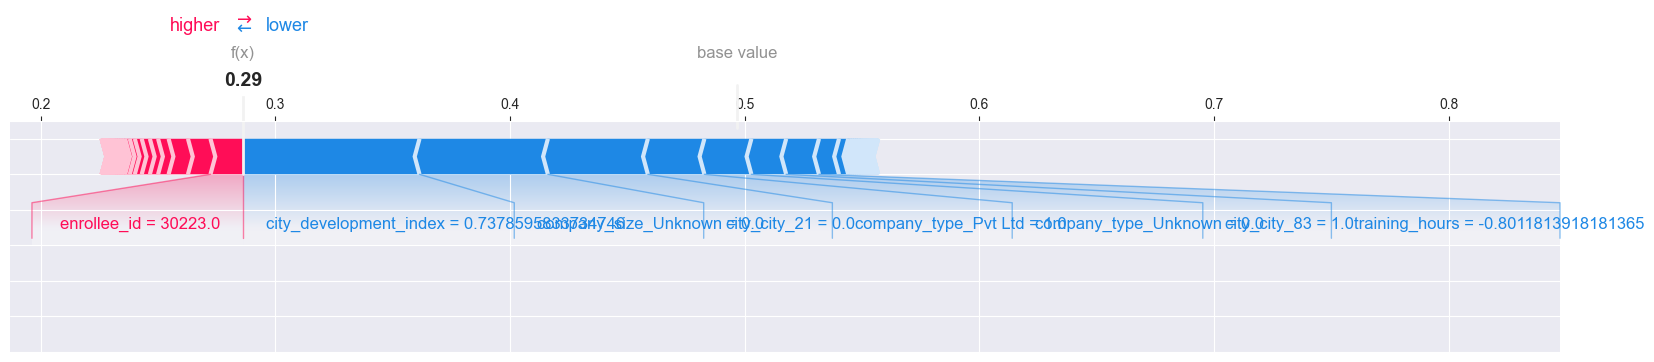

In [99]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values_rf[idx],
    X_test.iloc[idx],
    matplotlib=True
)
